# Lab 4.2: Robustness, Attacks and Honest Explanations

AI for Cybersecurity (D7084E / D7041E), Group 6
Kirill Silchenko (kirsil-5@student.ltu.se) and Stefanos Ntentopoulos (stente-5@student.ltu.se)

Is a network flow an attack or normal traffic, and does the detector still work when the data are
imperfect or an attacker is trying to break it? Parts A-F of the lab in order: the baseline and the
always-benign model (A), noise and missing values (B), a greedy evasion attack with and without
network constraints (C), SHAP compared with what the attacker changed (D), an ensemble and
single- vs. group-feature removal (E), and three checks of whether SHAP and LIME are faithful (F).
`random_state=42` throughout. Run from top to bottom; the dataset is `data/processed/clean.csv`
(the cleaned CICIDS2017 table from Lab 1, see `data/README.md`).

*Generated by `tools/assemble.py` from the notebooks in `parts/`. Do not edit this file by hand.*

<!-- STEP A0 -->
## Setup: data, split, models and shared helpers

This section does what the lab's Section 4 asks: reuse the cleaned CICIDS data from Lab 1, rebuild the
same train / validation / test split, and train the three models (decision tree, logistic regression,
random forest of 300 trees) with `random_state=42`.

It also builds every shared name the later steps use (see the contract in `TASKLIST.md`, section 2.3):
the feature lists, the training standard deviations and medians, the correlation table, `report()`,
and the two fixed samples of test flows (`ATTACK_IDX`, `EXPLAIN_IDX`).

**Data note.** Lab 1 used CICIDS**2017** (all eight day-files, 20% stratified sample), not CICIDS2018
as the lab text says. The column names are therefore the long 2017 ones (`Fwd Packet Length Mean`
rather than `Fwd Pkt Len Mean`), about 15% of flows are attacks, and `Destination Port` and
`Protocol` were removed in Lab 1 as ID columns.

In [1]:
# STEP A0
# Install shap and lime only if they are missing (Colab). Locally they come from requirements.txt.
import importlib.util
import subprocess
import sys

_missing = [p for p in ("shap", "lime") if importlib.util.find_spec(p) is None]
if _missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *_missing])

In [2]:
# STEP A0
import os
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix, f1_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

SEED = 42

# scikit-learn 1.6.1 passes an option that newer scipy no longer knows; the warning is harmless.
warnings.filterwarnings("ignore", message="Unknown solver options")

# Part notebooks live in parts/; the hand-in notebook lives in the repository root. Work from the
# root in both cases, so that data/, models/ and results/ mean the same thing everywhere.
if Path.cwd().name == "parts":
    os.chdir("..")

DATA_FILE = Path("data/processed/clean.csv")
if not DATA_FILE.is_file() and Path("clean.csv").is_file():
    DATA_FILE = Path("clean.csv")              # Colab: clean.csv uploaded next to the notebook
MODEL_DIR = Path("models")
for folder in (MODEL_DIR, Path("results/figures"), Path("results/tables")):
    folder.mkdir(parents=True, exist_ok=True)

print(f"Python {sys.version.split()[0]}, scikit-learn {sklearn.__version__}, "
      f"numpy {np.__version__}, pandas {pd.__version__}")
print(f"Working directory: {Path.cwd()}")

Python 3.13.7, scikit-learn 1.6.1, numpy 2.5.3, pandas 3.0.6
Working directory: /home/steven/Desktop/AI-For-Cybersecurity-Lab-4.2-Robustness-attacks


<!-- STEP A0 -->
### Load the data and rebuild the Lab 1 split

The split is exactly Lab 1's (`lab1_pipeline/prepare.py`): 60 / 20 / 20, stratified on the **attack
type** so that every attack family keeps its share in all three parts, seed 42. The assertions stop
the notebook if the split is not the one Lab 1 used.

In [3]:
# STEP A0
if not DATA_FILE.is_file():
    raise FileNotFoundError(
        f"Cannot find {DATA_FILE}. Copy clean.csv into data/processed/ (see data/README.md).")

df = pd.read_csv(DATA_FILE)
attack_type = df["Label"]                               # "BENIGN", "DoS Hulk", "DDoS", ...
y = (attack_type != "BENIGN").astype(int)               # 1 = attack, 0 = benign
X = df.drop(columns=["Label"]).select_dtypes(include=[np.number])

# Same two cuts as Lab 1: first the test set (20%), then validation = 25% of the remaining 80%.
X_tmp, X_test, y_tmp, y_test, type_tmp, type_test = train_test_split(
    X, y, attack_type, test_size=0.20, stratify=attack_type, random_state=SEED)
X_train, X_val, y_train, y_val, type_train, type_val = train_test_split(
    X_tmp, y_tmp, type_tmp, test_size=0.25, stratify=type_tmp, random_state=SEED)
del X_tmp, y_tmp, type_tmp

assert X_train.shape == (267_984, 68), X_train.shape
assert X_val.shape == (89_328, 68), X_val.shape
assert X_test.shape == (89_329, 68), X_test.shape
assert int(y_test.sum()) == 13_461, int(y_test.sum())

for name, part, labels in (("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)):
    print(f"{name:<5} {len(part):>7,} rows   attack rate {labels.mean():.4f}")

train 267,984 rows   attack rate 0.1507
val    89,328 rows   attack rate 0.1507
test   89,329 rows   attack rate 0.1507


<!-- STEP A0 -->
### Shared feature information (measured on the training set only)

- `CONT_COLS` / `FLAG_COLS`: continuous columns, and the 0/1 flag columns (two or fewer distinct
  values). Noise in B1 is added to continuous columns only.
- `TRAIN_STD`, `TRAIN_MEDIAN`: the size of the noise (B1) and of the attacker's step (C1), and the
  value used for a missing feature (B2, F1). They come from the **training** set; measuring them on
  the test set would be leakage.
- `CORR`: absolute correlation between every pair of features, used to find the "twins" in E2 and
  F1.

In [4]:
# STEP A0
FEATURES = list(X_train.columns)
FLAG_COLS = [c for c in FEATURES if X_train[c].nunique() <= 2]
CONT_COLS = [c for c in FEATURES if c not in FLAG_COLS]

TRAIN_STD = X_train.std()
TRAIN_MEDIAN = X_train.median()
# Same numbers as X_train.corr().abs() (checked: differences below 1e-13), but about 7x faster.
CORR = pd.DataFrame(np.corrcoef(X_train.to_numpy(dtype=float), rowvar=False),
                    index=FEATURES, columns=FEATURES).abs()

print(f"{len(FEATURES)} features: {len(CONT_COLS)} continuous, {len(FLAG_COLS)} flag columns")
print("Flag columns:", ", ".join(FLAG_COLS))

68 features: 58 continuous, 10 flag columns
Flag columns: Fwd PSH Flags, Fwd URG Flags, FIN Flag Count, SYN Flag Count, RST Flag Count, PSH Flag Count, ACK Flag Count, URG Flag Count, CWE Flag Count, ECE Flag Count


<!-- STEP A0 -->
### `report()`: the scores the lab asks for

The lab says to always report macro-F1, recall, PR-AUC and FAR. `report()` returns those plus accuracy
and ROC-AUC, so the misleading scores can be shown next to the honest ones.

- **FAR** (false alarm rate) = FP / (FP + TN): the share of benign flows wrongly called attacks.
- **PR-AUC** = `average_precision_score`. Unlike ROC-AUC it is not inflated by the many benign flows.

It works with any model that has `predict` and `predict_proba` (the ensemble in E1 included).

In [5]:
# STEP A0
def false_alarm_rate(y_true, y_pred):
    """FP / (FP + TN): the share of benign flows that were called attacks."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0


def report(model, X, y):
    """Score a model on (X, y). X must be a DataFrame with the 68 raw feature columns."""
    y_pred = model.predict(X)
    y_score = model.predict_proba(X)[:, 1]
    return {
        "accuracy": accuracy_score(y, y_pred),
        "macro_f1": f1_score(y, y_pred, average="macro"),
        "recall": recall_score(y, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y, y_score),
        "pr_auc": average_precision_score(y, y_score),
        "far": false_alarm_rate(y, y_pred),
    }

<!-- STEP A0 -->
### The three models

All three take the **raw** 68 columns. Logistic regression needs scaled features, so the scaler sits
inside a `Pipeline` and is fitted on the training set only. That way noise, medians and attacker steps
are always applied in real units, to every model in the same way.

| Model | Settings | Why |
|---|---|---|
| Decision tree | `random_state=42`, no depth limit | The single, brittle model the lab contrasts with the forest |
| Logistic regression | `StandardScaler` + `LogisticRegression(max_iter=1000)` | A linear model with a different decision boundary |
| Random forest | 300 trees, `max_depth=20`, `n_jobs=-1` | 300 trees as the lab says; depth 20 is what Lab 1 chose on validation, and it keeps SHAP fast |

Training the forest takes a few minutes, so each model is saved in `models/` and loaded on later
runs. **Delete `models/*.joblib` to retrain from scratch** (the final check, T7, does this).

In [6]:
# STEP A0
MODEL_SPECS = {
    "tree": lambda: DecisionTreeClassifier(random_state=SEED),
    "logreg": lambda: Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED)),
    ]),
    "forest": lambda: RandomForestClassifier(n_estimators=300, max_depth=20,
                                             random_state=SEED, n_jobs=-1),
}


def load_or_train(name):
    """Load models/<name>.joblib if it fits the current features; otherwise train and save it."""
    path = MODEL_DIR / f"{name}.joblib"
    if path.is_file():
        model = joblib.load(path)
        if list(getattr(model, "feature_names_in_", [])) == FEATURES:
            print(f"  {name:<7} loaded from {path}")
            return model
        print(f"  {name:<7} cached file does not match the features; retraining")
    start = time.time()
    model = MODEL_SPECS[name]().fit(X_train, y_train)
    joblib.dump(model, path)
    print(f"  {name:<7} trained in {time.time() - start:.0f} s, saved to {path}")
    return model


MODELS = {name: load_or_train(name) for name in MODEL_SPECS}
tree, logreg, rf = MODELS["tree"], MODELS["logreg"], MODELS["forest"]

  tree    trained in 68 s, saved to models/tree.joblib


  logreg  trained in 235 s, saved to models/logreg.joblib


  forest  trained in 1611 s, saved to models/forest.joblib


<!-- STEP A0 -->
### Fixed samples of test flows, shared by several steps

- `ATTACK_IDX`: the **50 test flows the forest is most confident are attacks**, among real attacks it
  detects. C2 attacks these flows, E1 attacks them again with the ensemble, and F1 runs the deletion
  test on them, so all three talk about the same flows.
- `EXPLAIN_IDX`: 500 random test flows (seed 42). D1 explains all 500 with SHAP, D2 uses the first 200.

Both hold **positions**, so use them with `X_test.iloc[...]`.

In [7]:
# STEP A0
rf_proba_test = rf.predict_proba(X_test)[:, 1]
detected = np.flatnonzero((y_test.to_numpy() == 1) & (rf_proba_test >= 0.5))
# Highest probability first; "stable" keeps ties in test-set order, so the choice is reproducible.
ATTACK_IDX = detected[np.argsort(-rf_proba_test[detected], kind="stable")[:50]]

EXPLAIN_IDX = np.random.default_rng(SEED).choice(len(X_test), 500, replace=False)

print(f"ATTACK_IDX: 50 detected attacks, forest probability "
      f"{rf_proba_test[ATTACK_IDX].min():.3f}-{rf_proba_test[ATTACK_IDX].max():.3f}")
print("  attack types:", type_test.iloc[ATTACK_IDX].value_counts().to_dict())
print(f"EXPLAIN_IDX: {len(EXPLAIN_IDX)} random test flows, "
      f"{int(y_test.iloc[EXPLAIN_IDX].sum())} of them attacks")

ATTACK_IDX: 50 detected attacks, forest probability 1.000-1.000
  attack types: {'DDoS': 25, 'DoS Hulk': 22, 'DoS GoldenEye': 2, 'SSH-Patator': 1}
EXPLAIN_IDX: 500 random test flows, 68 of them attacks


In [8]:
# STEP A0
# Everything the later steps rely on (TASKLIST.md, section 2.3). Fail here, not halfway through Part F.
_shared = ["SEED", "X_train", "X_val", "X_test", "y_train", "y_val", "y_test", "FEATURES",
           "CONT_COLS", "FLAG_COLS", "TRAIN_STD", "TRAIN_MEDIAN", "CORR", "report", "MODELS",
           "tree", "logreg", "rf", "ATTACK_IDX", "EXPLAIN_IDX"]
missing = [name for name in _shared if name not in globals()]
assert not missing, f"setup did not create: {missing}"
print(f"Setup complete: {len(_shared)} shared names ready. The models are scored in step A2.")

Setup complete: 20 shared names ready. The models are scored in step A2.


<!-- STEP A1 -->
## Part A: The baseline

### Step A1: Check the data is healthy

Infinite or missing values would make the noise (Part B) and the attack (Part C) crash or produce
nonsense, so we check for them before anything else. We also count which columns are continuous and
which are 0/1 flags, because Part B adds noise to continuous columns only.

In [9]:
# STEP A1
print(f"X_train {X_train.shape}, X_val {X_val.shape}, X_test {X_test.shape}")
print(f"Share of attacks in the training labels: {y_train.mean():.4f}")

# np.isfinite is False for +inf, -inf and NaN, so one check covers infinities and missing values.
finite = {name: bool(np.isfinite(part).all().all())
          for name, part in (("train", X_train), ("val", X_val), ("test", X_test))}
print("All values finite:", finite)

if not all(finite.values()):
    # Not needed for our data (Lab 1 dropped every row with an infinity or NaN), but this is the fix:
    # turn infinities into NaN, then fill with the TRAINING median, never a test-set statistic.
    for part in (X_train, X_val, X_test):
        part.replace([np.inf, -np.inf], np.nan, inplace=True)
        part.fillna(TRAIN_MEDIAN, inplace=True)
assert all(np.isfinite(part).all().all() for part in (X_train, X_val, X_test))

print(f"\n{len(CONT_COLS)} continuous columns (more than two distinct values in training), "
      f"{len(FLAG_COLS)} flag columns:")
print("  " + ", ".join(FLAG_COLS))

X_train (267984, 68), X_val (89328, 68), X_test (89329, 68)
Share of attacks in the training labels: 0.1507


All values finite: {'train': True, 'val': True, 'test': True}



58 continuous columns (more than two distinct values in training), 10 flag columns:
  Fwd PSH Flags, Fwd URG Flags, FIN Flag Count, SYN Flag Count, RST Flag Count, PSH Flag Count, ACK Flag Count, URG Flag Count, CWE Flag Count, ECE Flag Count


In [10]:
# STEP A1
# Two things the later steps need to know about the continuous columns: are some values negative
# (matters for clipping noise at zero in B1), and how heavy-tailed are they (a few enormous values).
q = X_train[CONT_COLS].quantile([0.5, 0.99])
health = pd.DataFrame({
    "min": X_train[CONT_COLS].min(),
    "median": q.loc[0.5],
    "p99": q.loc[0.99],
    "max": X_train[CONT_COLS].max(),
    "max_over_p99": X_train[CONT_COLS].max() / q.loc[0.99].replace(0, np.nan),
})
negative = health.index[health["min"] < 0].tolist()
print(f"{len(negative)} continuous columns contain negative values in training:")
print("  " + ", ".join(negative))
print("\nMost heavy-tailed columns (maximum compared with the 99th percentile):")
print(health.sort_values("max_over_p99", ascending=False).head(5)[["median", "p99", "max"]]
      .to_string(float_format=lambda v: f"{v:,.0f}"))

summary = pd.DataFrame([{
    "train_rows": len(X_train), "val_rows": len(X_val), "test_rows": len(X_test),
    "features": len(FEATURES), "continuous": len(CONT_COLS), "flags": len(FLAG_COLS),
    "attack_rate_train": round(y_train.mean(), 4), "attack_rate_test": round(y_test.mean(), 4),
    "all_finite": all(finite.values()), "columns_with_negatives": len(negative),
}])
summary.to_csv("results/tables/A1_data_health.csv", index=False)
summary.T.rename(columns={0: "value"})

11 continuous columns contain negative values in training:
  Flow Duration, Flow Bytes/s, Flow Packets/s, Flow IAT Mean, Flow IAT Max, Flow IAT Min, Fwd Header Length, Bwd Header Length, Init_Win_bytes_forward, Init_Win_bytes_backward, min_seg_size_forward

Most heavy-tailed columns (maximum compared with the 99th percentile):
                             median    p99         max
Subflow Bwd Bytes               190 91,561 593,469,129
Total Length of Bwd Packets     190 91,561 593,000,000
act_data_pkt_fwd                  1     32     192,326
Subflow Bwd Packets               2     69     272,353
Total Backward Packets            2     69     272,353


,value
train_rows,267984
val_rows,89328
test_rows,89329
features,68
continuous,58
flags,10
attack_rate_train,0.1507
attack_rate_test,0.1507
all_finite,True
columns_with_negatives,11


<!-- STEP A1 -->
**What we found.** About 15% of the flows are attacks in every part of the split. Every value is
finite: Lab 1 already dropped the rows where `Flow Bytes/s` or `Flow Packets/s` were infinite (a
division by a zero duration), so nothing had to be fixed here. 58 of the 68 columns are continuous and
only the 10 flag columns are 0/1. That is the opposite of the phishing data in Lab 4.1, where many
features were flags.

Two warnings for Part B. Several continuous columns contain negative values in the raw data (−1 means
"not recorded", and the header lengths have a known CICFlowMeter bug), so clipping noisy values at
zero would also change real data. And the columns are heavy-tailed: the largest values are many times
the 99th percentile, so noise sized by the standard deviation will hit rows unevenly.

<!-- STEP A2 -->
### Step A2: Score the three models, and the model that does nothing

`report()` (from the setup) already includes PR-AUC, so it returns macro-F1, recall, ROC-AUC, PR-AUC
and FAR, plus accuracy for comparison. The "always benign" model is scikit-learn's
`DummyClassifier(strategy="constant", constant=0)`: it answers *benign* for every flow, so it goes
through the same `report()` as the real models. Its accuracy is `1 - y_test.mean()` and its recall
is zero.

In [11]:
# STEP A2
from sklearn.dummy import DummyClassifier

always_benign = DummyClassifier(strategy="constant", constant=0).fit(X_train, y_train)

baseline = pd.DataFrame(
    {name: report(model, X_test, y_test)
     for name, model in [("always benign", always_benign), *MODELS.items()]}).T
baseline.index.name = "model"

# The always-benign accuracy and recall must be exactly what the lab says.
assert np.isclose(baseline.loc["always benign", "accuracy"], 1 - y_test.mean())
assert baseline.loc["always benign", "recall"] == 0

baseline.to_csv("results/tables/A2_baseline.csv", float_format="%.4f")
baseline.round(4)

,accuracy,macro_f1,recall,roc_auc,pr_auc,far
model,,,,,,
always benign,0.8493,0.4593,0.0000,0.5000,0.1507,0.0000
tree,0.9985,0.9970,0.9950,0.9971,0.9907,0.0009
logreg,0.9720,0.9416,0.8320,0.9915,0.9693,0.0032
forest,0.9984,0.9968,0.9923,0.9999,0.9998,0.0006


In [12]:
# STEP A2
# Numbers for the two "Check yourself" questions.
acc_benign = baseline.loc["always benign", "accuracy"]
acc_forest = baseline.loc["forest", "accuracy"]
print(f"Accuracy: always benign {acc_benign:.4f}, forest {acc_forest:.4f}, "
      f"margin {acc_forest - acc_benign:+.4f}")
print(f"Errors:   always benign {1 - acc_benign:.4f}, forest {1 - acc_forest:.4f} "
      f"(the forest removes {1 - (1 - acc_forest) / (1 - acc_benign):.1%} of the errors)")
print(f"Recall:   always benign 0.0000, forest {baseline.loc['forest', 'recall']:.4f}")

real = baseline.drop(index="always benign")
print("\nBetween the three real models:")
for col in ("roc_auc", "pr_auc"):
    print(f"  {col:<8} from {real[col].min():.4f} to {real[col].max():.4f}  "
          f"(spread {real[col].max() - real[col].min():.4f})")
print(f"Gap between ROC-AUC and PR-AUC per model:")
print((real["roc_auc"] - real["pr_auc"]).round(4).to_string())

Accuracy: always benign 0.8493, forest 0.9984, margin +0.1491
Errors:   always benign 0.1507, forest 0.0016 (the forest removes 98.9% of the errors)
Recall:   always benign 0.0000, forest 0.9923

Between the three real models:
  roc_auc  from 0.9915 to 0.9999  (spread 0.0084)
  pr_auc   from 0.9693 to 0.9998  (spread 0.0305)
Gap between ROC-AUC and PR-AUC per model:
model
tree      0.0064
logreg    0.0222
forest    0.0002


<!-- STEP A2 -->
**What we found.** The always-benign model is **84.9% accurate** and catches **no attack at all**
(recall 0, macro-F1 0.46, PR-AUC 0.15, which equals the attack rate). Every later number in this lab
is compared with this table.

**Check yourself 1: how far above the always-benign accuracy is the forest?** 0.9984 against 0.8493,
a margin of +0.149. That sounds like "15 points better", but it hides most of the story. The honest
comparisons are the errors and the recall: the forest makes 0.16% errors instead of 15.07% (it removes
about 99% of them), and it catches 99.2% of the attacks instead of none. With attacks at 15% the
imbalance is milder than the lab's 2% example, so accuracy is less misleading here, but it still
makes a model that does nothing look good.

**Check yourself 2: ROC-AUC or PR-AUC, which moved more?** PR-AUC. Across the three models ROC-AUC only
spans 0.991–1.000 (a spread of 0.008), while PR-AUC spans 0.969–1.000 (0.031, more than three times as
much). Logistic regression loses 0.022 between its ROC-AUC and its PR-AUC, the forest only 0.0002.
ROC-AUC is built from the false-positive *rate*, which is divided by the 75,868 benign test flows, so
a few hundred false alarms barely move it. PR-AUC uses *precision*, which compares those false
alarms with the 13,461 attacks, so the same false alarms cost much more. That is why the lab says to
report PR-AUC on imbalanced data.

**Side note.** The single tree has the best macro-F1 (0.9970, against 0.9968 for the forest), but the
lowest ROC-AUC of the three real models. A fully grown tree gives almost every flow a probability of
exactly 0 or 1, so it decides well but cannot rank flows by how suspicious they are. Part B will show
whether its decisions also survive messy data.

<!-- STEP B1 -->
## Part B: Break the data by accident

### Step B1: Add noise

A real sensor does not measure perfectly. `add_noise` adds a small random amount to every continuous
feature and leaves the 0/1 flags alone. For each column the noise is drawn from a normal distribution
with mean 0 and standard deviation `level × (standard deviation of that column)`.

- The standard deviation comes from the **reference set**, which we always pass as the **training set**.
  Measuring it on the test set would be leakage.
- The same seed is used at every level, so the levels differ only in the *size* of the noise, not in
  its random pattern.
- **Clipping.** Durations, counts and byte totals cannot be negative in reality, so after adding noise
  we clip at zero, but only in the columns whose training minimum is ≥ 0. Eleven columns already
  contain negative values in the real data (−1 = "not recorded", and CICFlowMeter bugs, see A1);
  clipping those at zero would change genuine measurements, not just remove impossible noise. We run
  B1 with and without clipping (extra X2) to see whether this choice matters.

In [13]:
# STEP B1
import matplotlib.pyplot as plt

# Columns that are never negative in the training data: clipping these at zero only removes
# impossible values that the noise created (a negative packet count). Columns that are already
# negative in real data (-1 = "not recorded") are left alone, so clipping never edits a real value.
NONNEG_COLS = [c for c in CONT_COLS if X_train[c].min() >= 0]


def add_noise(X, X_ref, level, seed=SEED, clip=True):
    """Noisy copy of X: Gaussian noise of width level * std(X_ref) on every continuous column.

    X_ref must be the training set (std measured there, never on the data being scored).
    The 0/1 flag columns are not touched. With clip=True, columns that are never negative in
    X_ref are clipped at zero after the noise is added.
    """
    noisy = X.copy()
    if level == 0:
        return noisy
    rng = np.random.default_rng(seed)
    std = X_ref[CONT_COLS].std().to_numpy()
    values = noisy[CONT_COLS].to_numpy(dtype=float)
    values += rng.standard_normal(values.shape) * (level * std)
    if clip:
        nonneg = np.isin(CONT_COLS, [c for c in CONT_COLS if X_ref[c].min() >= 0])
        values[:, nonneg] = np.maximum(values[:, nonneg], 0.0)
    noisy[CONT_COLS] = values
    return noisy


# Sanity checks: flags untouched, level 0 changes nothing, clipped columns never negative.
_check = add_noise(X_test.iloc[:1000], X_train, 0.5)
assert _check[FLAG_COLS].equals(X_test.iloc[:1000][FLAG_COLS])
assert add_noise(X_test.iloc[:1000], X_train, 0.0).equals(X_test.iloc[:1000])
assert (_check[NONNEG_COLS] >= 0).all().all()
print(f"{len(NONNEG_COLS)} of {len(CONT_COLS)} continuous columns are clipped at zero")

47 of 58 continuous columns are clipped at zero


In [14]:
# STEP B1
NOISE_LEVELS = [0.00, 0.05, 0.10, 0.20, 0.50]

rows = []
for clip in (True, False):
    for level in NOISE_LEVELS:
        X_noisy = add_noise(X_test, X_train, level, clip=clip)
        for name, model in MODELS.items():
            rows.append({"clip": clip, "level": level, "model": name,
                         **report(model, X_noisy, y_test)})
noise_all = pd.DataFrame(rows)
noise_all.to_csv("results/tables/B1_noise.csv", index=False, float_format="%.4f")

noise = noise_all[noise_all["clip"]]                      # the main result: with clipping
print("Macro-F1 (rows: model, columns: noise level)")
print(noise.pivot(index="model", columns="level", values="macro_f1").round(4).to_string())
print("\nRecall")
print(noise.pivot(index="model", columns="level", values="recall").round(4).to_string())

Macro-F1 (rows: model, columns: noise level)
level     0.00    0.05    0.10    0.20    0.50
model                                         
forest  0.9968  0.5212  0.5082  0.4970  0.4798
logreg  0.9416  0.9085  0.8561  0.7521  0.5964
tree    0.9970  0.3992  0.3961  0.3962  0.3946

Recall
level     0.00    0.05    0.10    0.20    0.50
model                                         
forest  0.9923  0.0633  0.0494  0.0377  0.0202
logreg  0.8320  0.8364  0.8308  0.7920  0.7029
tree    0.9950  0.1092  0.1079  0.1126  0.1332


In [15]:
# STEP B1
# How much each model lost at each level, compared with its clean score.
clean = noise[noise["level"] == 0].set_index("model")
drop = noise.set_index(["model", "level"])[["macro_f1", "recall", "pr_auc", "far"]]
drop = drop - clean[["macro_f1", "recall", "pr_auc", "far"]].reindex(drop.index, level="model").to_numpy()
print("Change from the clean score (negative = worse, except FAR where positive = worse)")
print(drop.round(4).to_string())

Change from the clean score (negative = worse, except FAR where positive = worse)
              macro_f1  recall  pr_auc     far
model  level                                  
tree   0.00     0.0000  0.0000  0.0000  0.0000
logreg 0.00     0.0000  0.0000  0.0000  0.0000
forest 0.00     0.0000  0.0000  0.0000  0.0000
tree   0.05    -0.5978 -0.8858 -0.8506  0.3389
logreg 0.05    -0.0331  0.0044 -0.0316  0.0225
forest 0.05    -0.4756 -0.9290 -0.1681 -0.0006
tree   0.10    -0.6009 -0.8872 -0.8506  0.3452
logreg 0.10    -0.0855 -0.0012 -0.0797  0.0601
forest 0.10    -0.4886 -0.9429 -0.2142 -0.0006
tree   0.20    -0.6008 -0.8824 -0.8509  0.3489
logreg 0.20    -0.1896 -0.0400 -0.1953  0.1454
forest 0.20    -0.4998 -0.9545 -0.2615 -0.0006
tree   0.50    -0.6024 -0.8618 -0.8521  0.3690
logreg 0.50    -0.3452 -0.1291 -0.4555  0.3116
forest 0.50    -0.5170 -0.9721 -0.3252 -0.0006


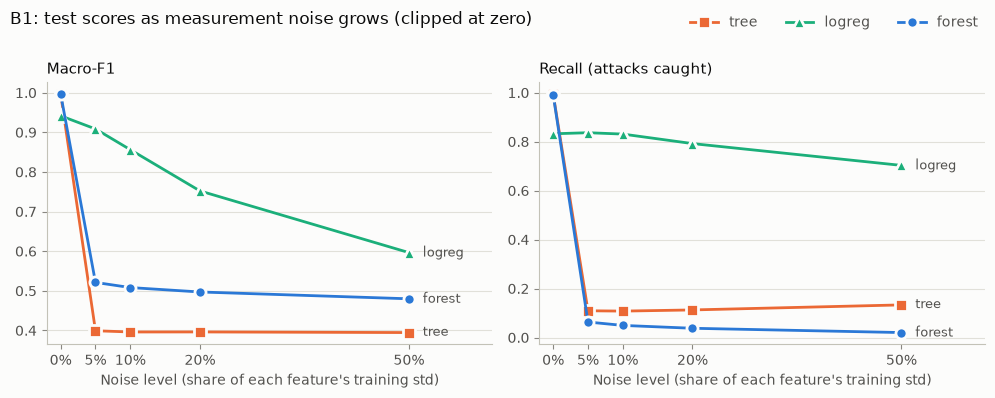

In [16]:
# STEP B1
# Figure: macro-F1 and recall against the noise level, one line per model (with clipping).
# Fixed colour per model (the same in every figure of this lab), plus a marker shape and a direct
# label, so a model is never identified by colour alone.
MODEL_COLORS = {"forest": "#2a78d6", "tree": "#eb6834", "logreg": "#1baf7a"}
MODEL_MARKERS = {"forest": "o", "tree": "s", "logreg": "^"}
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"


def style_axes(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelcolor=INK_2)


def label_line_ends(ax, ends, min_gap):
    """Write each model's name at the right end of its line, nudged apart so labels never overlap."""
    placed = []
    for name, y in sorted(ends.items(), key=lambda kv: kv[1]):
        y_text = max(y, placed[-1] + min_gap) if placed else y
        placed.append(y_text)
        ax.annotate(name, xy=(NOISE_LEVELS[-1], y), xytext=(10, 0), textcoords="offset points",
                    va="center", color=INK_2, fontsize=9)
        if abs(y_text - y) > 1e-9:   # move the text, keep the anchor on the line
            ax.texts[-1].set_position((NOISE_LEVELS[-1], y_text))
            ax.texts[-1].xyann = (10, 0)


fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor=SURFACE)
for ax, metric, title in zip(axes, ("macro_f1", "recall"), ("Macro-F1", "Recall (attacks caught)")):
    style_axes(ax)
    ends = {}
    for name in MODELS:
        part = noise[noise["model"] == name]
        ax.plot(part["level"], part[metric], color=MODEL_COLORS[name], linewidth=2,
                marker=MODEL_MARKERS[name], markersize=8, markeredgecolor=SURFACE,
                markeredgewidth=2, label=name)
        ends[name] = part[metric].iloc[-1]
    lo, hi = ax.get_ylim()
    label_line_ends(ax, ends, min_gap=(hi - lo) * 0.06)
    ax.set_xlim(-0.02, NOISE_LEVELS[-1] + 0.12)
    ax.set_xticks(NOISE_LEVELS)
    ax.set_xticklabels([f"{l:.0%}" for l in NOISE_LEVELS])
    ax.set_xlabel("Noise level (share of each feature's training std)", color=INK_2)
    ax.set_title(title, color=INK, loc="left", fontsize=11)
fig.suptitle("B1: test scores as measurement noise grows (clipped at zero)", color=INK, x=0.01,
             ha="left", fontsize=12)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=3, frameon=False, labelcolor=INK_2,
           bbox_to_anchor=(0.99, 1.0))
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig("results/figures/B1_noise_curves.png", dpi=150, facecolor=SURFACE)
plt.show()

<!-- STEP B1 -->
**Why do the trees collapse at only 5%?** The lab expects the forest to lose very little, but on our
data both tree models lose almost all their recall. The next cell shows why. The noise width is a
share of each column's *standard deviation*, and A1 found extreme outliers (recording bugs, a few
flows lasting hours). Those outliers blow up the standard deviation, so for some columns "5% of the
std" is hundreds or thousands of times the spread of an ordinary flow. The cell measures three things
on 3,000 test attacks:

1. how much bigger the std is than a robust spread (the interquartile range / 1.349, which ignores
   outliers);
2. forest and tree recall when **all** continuous columns get std-scaled noise at much smaller levels;
3. the same experiment with noise scaled by the robust spread instead of the std (for comparison
   only; the lab's method stays the main result).

In [17]:
# STEP B1
attack_rows = np.random.default_rng(SEED).choice(np.flatnonzero(y_test.to_numpy() == 1), 3000,
                                                 replace=False)
X_att = X_test.iloc[attack_rows]
robust_sd = (X_train[CONT_COLS].quantile(0.75) - X_train[CONT_COLS].quantile(0.25)) / 1.349

scale = pd.DataFrame({"train_std": TRAIN_STD[CONT_COLS], "robust_sd": robust_sd,
                      "median": TRAIN_MEDIAN[CONT_COLS]})
scale["std_over_robust"] = scale["train_std"] / scale["robust_sd"].replace(0, np.nan)
print("Columns whose std is most inflated by outliers:")
print(scale.sort_values("std_over_robust", ascending=False).head(6)
      .to_string(float_format=lambda v: f"{v:,.1f}"))

print("\nRecall on 3,000 test attacks, std-scaled noise on all continuous columns:")
for level in (0.0005, 0.001, 0.005, 0.01, 0.05):
    Xn = add_noise(X_att, X_train, level)
    print(f"  level {level:<7} forest {rf.predict(Xn).mean():.3f}   tree {tree.predict(Xn).mean():.3f}"
          f"   logreg {logreg.predict(Xn).mean():.3f}")

print("\nSame, but noise scaled by the robust spread instead of the std (comparison only):")
gauss = np.random.default_rng(SEED).standard_normal((len(X_att), len(CONT_COLS)))
for level in (0.05, 0.10, 0.20, 0.50):
    Xn = X_att.copy()
    vals = Xn[CONT_COLS].to_numpy(dtype=float) + gauss * level * robust_sd.to_numpy()
    nonneg = np.isin(CONT_COLS, NONNEG_COLS)
    vals[:, nonneg] = np.maximum(vals[:, nonneg], 0.0)
    Xn[CONT_COLS] = vals
    print(f"  level {level:<5} forest {rf.predict(Xn).mean():.3f}   tree {tree.predict(Xn).mean():.3f}"
          f"   logreg {logreg.predict(Xn).mean():.3f}")

Columns whose std is most inflated by outliers:
               train_std  robust_sd  median  std_over_robust
Active Max   1,117,723.2        0.7     0.0      1,507,808.6
Active Mean    694,542.0        0.7     0.0        936,937.2
Active Min     611,394.1        0.7     0.0        824,770.6
Bwd IAT Min  9,281,328.6       35.6     3.0        260,844.0
Fwd IAT Min  9,547,685.8       49.7     3.0        192,236.2
Flow IAT Min 3,168,819.1       56.3     4.0         56,246.5

Recall on 3,000 test attacks, std-scaled noise on all continuous columns:


  level 0.0005  forest 0.859   tree 0.668   logreg 0.841


  level 0.001   forest 0.794   tree 0.500   logreg 0.840


  level 0.005   forest 0.375   tree 0.203   logreg 0.835


  level 0.01    forest 0.206   tree 0.154   logreg 0.835


  level 0.05    forest 0.072   tree 0.119   logreg 0.837

Same, but noise scaled by the robust spread instead of the std (comparison only):


  level 0.05  forest 0.768   tree 0.475   logreg 0.822


  level 0.1   forest 0.750   tree 0.296   logreg 0.814
  level 0.2   forest 0.740   tree 0.197   logreg 0.805


  level 0.5   forest 0.716   tree 0.142   logreg 0.763


<!-- STEP B1 -->
**What we found (B1).**

| Noise level | 0% | 5% | 10% | 20% | 50% |
|---|---|---|---|---|---|
| forest macro-F1 / recall | 0.997 / 0.992 | 0.521 / 0.063 | 0.508 / 0.049 | 0.497 / 0.038 | 0.480 / 0.020 |
| tree macro-F1 / recall | 0.997 / 0.995 | 0.399 / 0.109 | 0.396 / 0.108 | 0.396 / 0.113 | 0.395 / 0.133 |
| logreg macro-F1 / recall | 0.942 / 0.832 | 0.909 / 0.836 | 0.856 / 0.831 | 0.752 / 0.792 | 0.596 / 0.703 |

Unlike the lab's expectation, the forest does **not** survive 5% noise on our data: it loses 93% of its
recall and calls nearly every flow benign (its FAR drops to 0). The single tree loses as much recall
*and* starts raising false alarms on a third of the benign flows (FAR 0.34), which is close to
guessing. Logistic regression, the weakest model on clean data, is by far the most robust: at 5% it
keeps 0.84 recall.

The diagnostic cell explains why. The standard deviation of several columns is inflated by outliers by
a factor of 50,000 to 1,500,000 (`Active …`, `Fwd/Bwd/Flow IAT Min`). For those columns even 0.05% of
the std is a huge change for an ordinary flow, and the trees split on exactly those small timing values
(a flood attack sends packets microseconds apart). Even at a level of 0.0005 the forest's recall falls
to 0.86. Noise on **one** column at a time barely hurts (we checked: each costs less than 0.01 recall),
because its twins still carry the signal; noise on all columns at once removes every twin together.
Logistic regression is protected by its scaler: it reads each feature in units of the training std,
so to it the noise really is only 5%. With noise sized by a robust spread instead of the std, the
forest keeps about 0.75 recall at every level and the tree falls more slowly. So the damage is not
just uneven, as the lab's hint warns: it is dominated by the heavy tails.

**Check yourself: why does a single tree fall apart faster than a forest of 300 trees?** At small
noise levels it does: at level 0.001 the tree keeps 0.50 recall and the forest 0.79, at 0.005 the tree
0.20 and the forest 0.38. One tree has one path per flow, so a single threshold crossed by noise flips
its answer. The forest averages 300 trees built on different bootstrap samples and feature subsets, so
a flipped tree is outvoted until noise crosses the thresholds of most trees at once. At 5% std-scaled
noise that happens for both, because all trees rely on the same timing features. The tree's scores
are still worse at every level above 0 (macro-F1 0.40 vs 0.52 at 5%). Its slightly higher recall is
not detection: it comes with a FAR of 0.34.

**Check yourself: did clipping at zero change the results, and is a negative packet count a fair test?**
See X2 below: clipping changed **nothing** for the tree and the forest (identical to 4 decimals) and
improved logistic regression's macro-F1 by up to 0.024. For the trees, every split threshold on a
never-negative column lies at or above zero, so −5 and 0 land on the same side of every split. A
negative packet count is not a fair test: it describes a flow that cannot exist, so a model that fails
on it has not shown a weakness that matters in production. We therefore report the clipped run.

<!-- STEP B2 -->
### Step B2: Lose some features

A collector under load drops fields. `add_missing` simulates that: in every row it picks a random 10%
of the features (7 of the 68, a different 7 in each row) and replaces them with the **training**
median, which is the ordinary value a model should assume when it is told nothing.

In [18]:
# STEP B2
def add_missing(X, frac, seed=SEED):
    """Copy of X where round(frac * n_features) random features per row are set to TRAIN_MEDIAN."""
    out = X.to_numpy(dtype=float, copy=True)
    k = int(round(frac * X.shape[1]))
    if k > 0:
        rng = np.random.default_rng(seed)
        # k random columns per row: the positions of the k smallest of a row of random numbers.
        cols = np.argpartition(rng.random(out.shape), k - 1, axis=1)[:, :k]
        out[np.arange(len(out))[:, None], cols] = TRAIN_MEDIAN.to_numpy()[cols]
    return pd.DataFrame(out, index=X.index, columns=X.columns)


_check = add_missing(X_test.iloc[:1000], 0.10)
_changed = (_check.to_numpy() != X_test.iloc[:1000].to_numpy())
assert _changed.sum(axis=1).max() <= 7          # at most 7 values per row change (fewer if already = median)
print(f"Per row, {int(round(0.10 * len(FEATURES)))} of {len(FEATURES)} features are replaced "
      f"by the training median ({7 / len(FEATURES):.1%})")

Per row, 7 of 68 features are replaced by the training median (10.3%)


In [19]:
# STEP B2
X_missing = add_missing(X_test, 0.10)
missing = pd.DataFrame({name: report(model, X_missing, y_test) for name, model in MODELS.items()}).T
missing.index.name = "model"

clean_scores = baseline.loc[list(MODELS)]               # A2: clean test scores
noise5 = noise[noise["level"] == 0.05].set_index("model")[missing.columns]
compare = pd.concat({"clean": clean_scores, "10% missing": missing, "5% noise": noise5}, axis=1)
compare = compare.swaplevel(axis=1)[["macro_f1", "recall", "pr_auc", "far"]]
missing.to_csv("results/tables/B2_missing.csv", float_format="%.4f")
compare.round(4)

macro_f1                       recall                       pr_auc  \
          clean 10% missing 5% noise   clean 10% missing 5% noise   clean   
model                                                                       
tree     0.9970      0.8763   0.3992  0.9950      0.7462   0.1092  0.9907   
logreg   0.9416      0.7776   0.9085  0.8320      0.6092   0.8364  0.9693   
forest   0.9968      0.9900   0.5212  0.9923      0.9681   0.0633  0.9998   

                                far                       
       10% missing 5% noise   clean 10% missing 5% noise  
model                                                     
tree        0.6612   0.1401  0.0009      0.0262   0.3398  
logreg      0.6520   0.9377  0.0032      0.0626   0.0257  
forest      0.9992   0.8317  0.0006      0.0003   0.0000

<!-- STEP B2 -->
**What we found (B2).** With 10% of each flow's values replaced by the training median, the forest
barely notices (macro-F1 0.997 → 0.990, recall 0.992 → 0.968). The tree loses a quarter of its recall
(0.995 → 0.746) and logistic regression the most (0.832 → 0.609, with its FAR rising from 0.003 to
0.063).

**Check yourself: which does more damage, noise or missing values?** It depends on the model, which is
the main lesson of Part B. For the tree models, noise is far worse: 5% noise leaves the forest 0.06
recall, 10% missing values leave it 0.97. For logistic regression it is the other way round: 5% noise
leaves 0.84 recall, 10% missing values 0.61. A median is an ordinary value for a tree, which simply
follows the "typical flow" branch for that feature while the other 61 features still decide. For a
linear model, replacing an attack's extreme value with the median removes a large part of the evidence
in one jump, and seven such jumps per flow add up. No model is safest against both kinds of damage:
the forest is safest when fields go missing, logistic regression when measurements are noisy.

<!-- STEP C1 -->
## Part C: Break the model on purpose

### Step C1: Sort the features and set a budget

An evasion attack is only honest if the attacker changes things a real attacker can change (lab
section 3.4). The attacker sends the **forward** traffic, so they can pad packets and wait longer. They
do not control the victim's replies, and they cannot finish the attack with fewer packets than it
needs. Every feature therefore goes into one of three groups:

| Group | Meaning | Why |
|---|---|---|
| **Free** | timing (inter-arrival times, idle and active timers, flow duration) and forward packet / header / segment sizes | Waiting longer and padding packets cost the attacker almost nothing |
| **Costly** | forward packet and byte counts (`Total Fwd Packets`, `Total Length of Fwd Packets`, forward subflows, forward data packets) | Possible, but every extra packet is more work and makes the attack louder |
| **Fixed** | everything the responder produces (all backward features, its initial window), all flag counts, and every feature we are unsure about | The victim's network stack produces these; the attacker cannot touch them |

The groups are assigned with **name rules in code**, not by hand, in this order: backward or flag →
Fixed; timing → Free; forward sizes → Free; forward counts → Costly; anything else → Fixed. When in
doubt, Fixed: an attack that is weaker than reality is a safer mistake than one that lets the attacker
do the impossible.

Our data has no `Destination Port` or `Protocol` (Lab 1 removed them as ID columns), so those two
Fixed features from the lab text do not appear.

In [20]:
# STEP C1
FREE_SIZES = ["Fwd Header Length", "Avg Fwd Segment Size", "min_seg_size_forward"]
COSTLY_COUNTS = ["Total Fwd Packets", "Total Length of Fwd Packets", "Subflow Fwd Packets",
                 "Subflow Fwd Bytes", "act_data_pkt_fwd"]


def assign_group(name):
    """Free / Costly / Fixed from the feature name, plus the rule that decided it.

    The order matters: the backward check comes first, otherwise 'Bwd IAT Mean' would be Free
    because it contains 'IAT'.
    """
    if "Bwd" in name or "backward" in name.lower():
        return "Fixed", "backward direction: produced by the victim"
    if "Flag" in name:
        return "Fixed", "flag: set by the network stack / responder"
    if any(key in name for key in ("IAT", "Idle", "Active")) or name == "Flow Duration":
        return "Free", "timing: the attacker can wait longer"
    if name.startswith("Fwd Packet Length") or name in FREE_SIZES:
        return "Free", "forward size: the attacker can pad packets"
    if name in COSTLY_COUNTS:
        return "Costly", "forward count: more packets, a louder attack"
    return "Fixed", "unsure (mixes both directions or is derived): Fixed to be safe"


_assigned = {name: assign_group(name) for name in FEATURES}
GROUP = {name: group for name, (group, _) in _assigned.items()}
GROUP_RULE = {name: rule for name, (_, rule) in _assigned.items()}

assert set(GROUP) == set(FEATURES)
counts = pd.Series(GROUP).value_counts().reindex(["Free", "Costly", "Fixed"])
print(counts.to_string())
assert counts.to_dict() == {"Free": 25, "Costly": 5, "Fixed": 38}
for group in ("Free", "Costly", "Fixed"):
    names = [f for f in FEATURES if GROUP[f] == group]
    print(f"\n{group} ({len(names)}):\n  " + ", ".join(names))

Free      25
Costly     5
Fixed     38

Free (25):
  Flow Duration, Fwd Packet Length Max, Fwd Packet Length Min, Fwd Packet Length Mean, Fwd Packet Length Std, Flow IAT Mean, Flow IAT Std, Flow IAT Max, Flow IAT Min, Fwd IAT Total, Fwd IAT Mean, Fwd IAT Std, Fwd IAT Max, Fwd IAT Min, Fwd Header Length, Avg Fwd Segment Size, min_seg_size_forward, Active Mean, Active Std, Active Max, Active Min, Idle Mean, Idle Std, Idle Max, Idle Min

Costly (5):
  Total Fwd Packets, Total Length of Fwd Packets, Subflow Fwd Packets, Subflow Fwd Bytes, act_data_pkt_fwd

Fixed (38):
  Total Backward Packets, Total Length of Bwd Packets, Bwd Packet Length Max, Bwd Packet Length Min, Bwd Packet Length Mean, Bwd Packet Length Std, Flow Bytes/s, Flow Packets/s, Bwd IAT Total, Bwd IAT Mean, Bwd IAT Std, Bwd IAT Max, Bwd IAT Min, Fwd PSH Flags, Fwd URG Flags, Bwd Header Length, Fwd Packets/s, Bwd Packets/s, Min Packet Length, Max Packet Length, Packet Length Mean, Packet Length Std, Packet Length Variance, FIN

In [21]:
# STEP C1
# The Fixed features that are Fixed only because we were unsure, with the reason.
unsure = [f for f in FEATURES if GROUP_RULE[f].startswith("unsure")]
print(f"{len(unsure)} features are Fixed by the 'when unsure, Fixed' rule:")
for f in unsure:
    print(f"  {f}")

11 features are Fixed by the 'when unsure, Fixed' rule:
  Flow Bytes/s
  Flow Packets/s
  Fwd Packets/s
  Min Packet Length
  Max Packet Length
  Packet Length Mean
  Packet Length Std
  Packet Length Variance
  Down/Up Ratio
  Average Packet Size
  Init_Win_bytes_forward


<!-- STEP C1 -->
**Why the "unsure" features are Fixed.** They fall in two kinds.

- *Mixed direction*: `Min/Max Packet Length`, `Packet Length Mean/Std/Variance`, `Average Packet Size`
  and `Down/Up Ratio` combine the attacker's packets with the victim's replies. The attacker can move
  only part of them, and not reliably.
- *Derived rates*: `Flow Bytes/s`, `Flow Packets/s` and `Fwd Packets/s` are computed from counts and
  duration. Waiting longer *lowers* them, so the attacker cannot raise them independently.

`Init_Win_bytes_forward` is set by the attacker's own TCP stack and could arguably be Costly. We keep
it Fixed for now; if C2's constrained attack evades nothing, it is the first candidate to move (the lab
allows this, as long as the report says so).

<!-- STEP C1 -->
### The constraint check and the budget

- `can_change(feature, old_value, new_value)` is `True` only when the feature is Free or Costly **and**
  the new value is at least the old one. The attacker can add packets and wait longer, never remove or
  speed up.
- **Budget:** one step raises one feature by at most **half its training standard deviation**, and at
  most **five features** may change in total.

In [22]:
# STEP C1
STEP_SIZE = 0.5 * TRAIN_STD          # pandas Series: the largest single-step increase per feature
MAX_CHANGES = 5                      # at most five different features may change per flow
CHANGEABLE = [f for f in FEATURES if GROUP[f] in ("Free", "Costly")]


def can_change(feature, old_value, new_value):
    """True only if the attacker may move this feature from old_value to new_value."""
    return GROUP[feature] in ("Free", "Costly") and new_value >= old_value


# Tests: no Fixed feature can ever change; nothing can decrease; Free and Costly can increase.
for f in FEATURES:
    if GROUP[f] == "Fixed":
        assert not can_change(f, 0.0, 1.0) and not can_change(f, 5.0, 5.0)
    else:
        assert can_change(f, 0.0, STEP_SIZE[f]) and can_change(f, 3.0, 3.0)
        assert not can_change(f, 1.0, 0.0)
print(f"can_change tests passed: {len(CHANGEABLE)} changeable features, "
      f"{len(FEATURES) - len(CHANGEABLE)} Fixed, none of which can change")

can_change tests passed: 30 changeable features, 38 Fixed, none of which can change


<!-- STEP C1 -->
### What one step means in real units

Part B showed that the standard deviations of our columns are inflated by outliers. The step size is
half a standard deviation, so it is worth seeing what that means for a typical flow before running the
attack: a "small" step can be huge compared with the median.

In [23]:
# STEP C1
def unit(name):
    """Unit of a changeable feature, for reading the table below."""
    if any(key in name for key in ("IAT", "Idle", "Active", "Duration")):
        return "µs"
    if "Length" in name or "Bytes" in name or "Size" in name or "seg_size" in name:
        return "bytes"
    return "packets"


steps = pd.DataFrame({
    "group": [GROUP[f] for f in CHANGEABLE],
    "unit": [unit(f) for f in CHANGEABLE],
    "train_median": TRAIN_MEDIAN[CHANGEABLE],
    "step_size": STEP_SIZE[CHANGEABLE],
}, index=pd.Index(CHANGEABLE, name="feature"))
steps["step_over_median"] = steps["step_size"] / steps["train_median"].abs().replace(0, np.nan)
print(steps.sort_values("step_over_median", ascending=False)
      .to_string(float_format=lambda v: f"{v:,.1f}"))

                              group     unit  train_median    step_size  step_over_median
feature                                                                                  
Fwd IAT Min                    Free       µs           3.0  4,773,842.9       1,591,281.0
Flow IAT Min                   Free       µs           4.0  1,584,409.6         396,102.4
Fwd IAT Total                  Free       µs         710.0 18,396,494.8          25,910.6
Fwd IAT Max                    Free       µs         632.5 13,509,832.8          21,359.4
Fwd IAT Mean                   Free       µs         375.5  5,262,371.2          14,014.3
min_seg_size_forward           Free    bytes          20.0     81,021.8           4,051.1
Fwd Header Length              Free    bytes          64.0     81,388.4           1,271.7
act_data_pkt_fwd             Costly  packets           1.0        344.4             344.4
Flow IAT Std                   Free       µs      17,985.3  4,433,822.0             246.5
Flow Durat

<!-- STEP C1 -->
**What one step means.** The steps are large compared with an ordinary flow, because the standard
deviations are inflated by outliers (B1). Most are still *possible* for a patient attacker: one step
adds 4.8 s to the shortest gap between the attacker's packets (`Fwd IAT Min`), 18 s to the flow
duration, 13 s to the idle timers, or about 360 extra packets (Costly).

Two Free steps are **not physically possible**:

- `min_seg_size_forward` is a header size, between 0 and 60 bytes for every normal flow, but one step
  adds 81,022 bytes. Its std comes almost entirely from a few recording-bug values around −84 million.
- `Fwd Header Length` (total header bytes sent by the attacker) gains 81,388 bytes per step. That
  would take roughly 2,000 extra packets, which is not free.

We keep the lab's budget exactly as written, so the attack follows the lab. In C2 we check which
features the successful evasions actually used; if they rely on these two, the report says so (and C2
can re-run with each new value capped at the training maximum as a sensitivity check). Rows whose
median is 0 (`Idle …`, `Active …`, `Fwd IAT Std`) show no ratio: most flows never go idle, so any
step is "infinitely" larger than the median.

In [24]:
# STEP C1
groups_table = pd.DataFrame({
    "feature": FEATURES,
    "group": [GROUP[f] for f in FEATURES],
    "rule": [GROUP_RULE[f] for f in FEATURES],
    "step_size": [STEP_SIZE[f] if GROUP[f] != "Fixed" else np.nan for f in FEATURES],
    "train_median": TRAIN_MEDIAN[FEATURES].to_numpy(),
})
groups_table.to_csv("results/tables/C1_feature_groups.csv", index=False, float_format="%.4g")
print("Saved results/tables/C1_feature_groups.csv")

Saved results/tables/C1_feature_groups.csv


<!-- STEP C2 -->
### Step C2: Run the attack, twice

**Greedy search.** Start from one attack flow. At each of five steps, try every change the attacker is
allowed to make, ask the forest for the attack probability of all candidates in **one**
`predict_proba` call, and keep the candidate that lowers the probability most. Stop early when no
candidate helps, or as soon as the flow is classified benign (probability below 0.5): at that point
the attacker has won, and more changes would only inflate the "features changed" count.

| Run | Which features | Direction | Step | Steps |
|---|---|---|---|---|
| **Constrained** | the 30 Free and Costly features, each new value checked with `can_change`, at most 5 different features | up only | +½ training std | 5 |
| **Unconstrained** | all 68 features | up or down | ±½ training std | 5 |
| Constrained + cap (check) | as constrained, but no value may exceed that feature's training maximum | up only | +½ std, capped | 5 |

The unconstrained run keeps the same step size and number of steps, so the **only** difference
between the first two runs is the network constraints. The third run answers C1's question: do the
evasions depend on the physically impossible steps (`min_seg_size_forward`, `Fwd Header Length`)?

In [25]:
# STEP C2
FEATURE_POS = {f: j for j, f in enumerate(FEATURES)}
TRAIN_MAX = X_train.max()


def greedy_attack(model, x_row, constrained=True, steps=5, cap=False):
    """Greedy evasion of one flow.

    x_row: one row as a DataFrame (X_test.iloc[[i]]). It is never modified; every candidate is a copy.
    constrained=True:  Free/Costly features only, increases only (can_change), at most MAX_CHANGES
                       different features. constrained=False: any feature, up or down.
    Both use the same step size (STEP_SIZE, half a training std) and the same number of steps, so the
    only difference between them is the network constraints.
    cap=True (constrained only): a new value may not exceed the feature's training maximum.
    Returns p_before, p_after, changed (one feature name per step taken) and x_adv (the edited row).
    """
    current = x_row.to_numpy(dtype=float)[0].copy()
    p_before = p = float(model.predict_proba(x_row)[0, 1])
    changed = []
    for _ in range(steps):
        if p < 0.5:                                   # already classified benign: the attacker stops
            break
        if constrained:
            budget_left = len(set(changed)) < MAX_CHANGES
            moves = [(f, +1) for f in CHANGEABLE if budget_left or f in changed]
        else:
            moves = [(f, sign) for f in FEATURES for sign in (+1, -1)]

        candidates, names = [], []
        for f, sign in moves:
            j = FEATURE_POS[f]
            new = current[j] + sign * STEP_SIZE[f]
            if constrained:
                if cap:
                    new = min(new, TRAIN_MAX[f])
                if new == current[j] or not can_change(f, current[j], new):
                    continue
            candidate = current.copy()
            candidate[j] = new
            candidates.append(candidate)
            names.append(f)
        if not candidates:
            break
        probs = model.predict_proba(pd.DataFrame(candidates, columns=FEATURES))[:, 1]
        best = int(np.argmin(probs))
        if probs[best] >= p:                          # nothing helps: stop early
            break
        current, p = candidates[best], float(probs[best])
        changed.append(names[best])

    x_adv = pd.DataFrame([current], columns=FEATURES, index=x_row.index)
    return {"p_before": p_before, "p_after": p, "changed": changed, "x_adv": x_adv}

In [26]:
# STEP C2
RUNS = {
    "constrained": dict(constrained=True),
    "unconstrained": dict(constrained=False),
    "constrained + cap": dict(constrained=True, cap=True),
}
X_test_before = X_test.copy()                         # to prove the attack never edits X_test

attack_runs, adv_rows = {}, {}
for run, options in RUNS.items():
    start = time.time()
    rows, advs = [], []
    for pos in ATTACK_IDX:
        result = greedy_attack(rf, X_test.iloc[[pos]], **options)
        rows.append({
            "test_position": int(pos),
            "attack_type": type_test.iloc[pos],
            "p_before": result["p_before"],
            "p_after": result["p_after"],
            "evaded": result["p_after"] < 0.5,
            "steps_taken": len(result["changed"]),
            "n_features_changed": len(set(result["changed"])),
            "changed": ";".join(result["changed"]),
        })
        advs.append(result["x_adv"])
    attack_runs[run] = pd.DataFrame(rows)
    adv_rows[run] = pd.concat(advs)
    print(f"{run:<18} done in {time.time() - start:.0f} s")

assert X_test.equals(X_test_before), "the attack modified X_test"
del X_test_before

# Constraint audit: in the constrained runs, every Fixed column is untouched and nothing went down.
original = X_test.iloc[ATTACK_IDX]
for run in ("constrained", "constrained + cap"):
    diff = adv_rows[run].to_numpy() - original.to_numpy(dtype=float)
    fixed = [FEATURE_POS[f] for f in FEATURES if GROUP[f] == "Fixed"]
    assert np.all(diff[:, fixed] == 0), f"{run}: a Fixed feature changed"
    assert np.all(diff >= 0), f"{run}: a feature decreased"
    if run == "constrained + cap":
        # A raised value never ends above the training maximum (values already above it are untouched).
        raised = diff > 0
        assert np.all(adv_rows[run].to_numpy()[raised] <= np.broadcast_to(TRAIN_MAX.to_numpy(), diff.shape)[raised])
print("Constraint audit passed: no Fixed feature changed and no value decreased in the constrained runs")

constrained        done in 25 s


unconstrained      done in 17 s


constrained + cap  done in 25 s


Constraint audit passed: no Fixed feature changed and no value decreased in the constrained runs


In [27]:
# STEP C2
comparison = pd.DataFrame({
    run: {
        "evaded (of 50)": int(df["evaded"].sum()),
        "mean p before": df["p_before"].mean(),
        "mean p after": df["p_after"].mean(),
        "mean features changed": df["n_features_changed"].mean(),
        "mean steps taken": df["steps_taken"].mean(),
    } for run, df in attack_runs.items()
}).T
comparison.index.name = "run"
comparison.to_csv("results/tables/C2_attack_comparison.csv", float_format="%.4f")

per_flow = pd.concat({run: df for run, df in attack_runs.items()}, names=["run"]).reset_index(level=0)
per_flow.to_csv("results/tables/C2_attack_per_flow.csv", index=False, float_format="%.4f")
comparison.round(4)

,evaded (of 50),mean p before,mean p after,mean features changed,mean steps taken
run,,,,,
constrained,9.0,1.0,0.7311,4.22,4.64
unconstrained,50.0,1.0,0.4312,2.78,2.78
constrained + cap,9.0,1.0,0.7311,4.22,4.64


In [28]:
# STEP C2
# Which attack types evaded, per run.
print(per_flow.pivot_table(index="attack_type", columns="run", values="evaded", aggfunc="sum")
      .assign(flows=type_test.iloc[ATTACK_IDX].value_counts()).to_string())

# Did the successful constrained evasions need the physically impossible header steps (C1 note)?
IMPOSSIBLE = ["min_seg_size_forward", "Fwd Header Length"]
for run in ("constrained", "constrained + cap"):
    ok = attack_runs[run][attack_runs[run]["evaded"]]
    uses = ok["changed"].apply(lambda s: any(f in s.split(";") for f in IMPOSSIBLE)).sum()
    print(f"\n{run}: {len(ok)} evasions, {uses} of them changed {' or '.join(IMPOSSIBLE)}")

# The probability path of the flows the constrained attack did not evade, for the write-up.
c = attack_runs["constrained"]
print("\nConstrained, not evaded: p_after distribution")
print(c.loc[~c["evaded"], "p_after"].describe().round(4).to_string())

run            constrained  constrained + cap  unconstrained  flows
attack_type                                                        
DDoS                     7                  7             25     25
DoS GoldenEye            2                  2              2      2
DoS Hulk                 0                  0             22     22
SSH-Patator              0                  0              1      1

constrained: 9 evasions, 2 of them changed min_seg_size_forward or Fwd Header Length

constrained + cap: 9 evasions, 2 of them changed min_seg_size_forward or Fwd Header Length

Constrained, not evaded: p_after distribution
count    41.0000
mean      0.7921
std       0.0663
min       0.5233
25%       0.7567
50%       0.8200
75%       0.8333
max       0.8667


In [29]:
# STEP C2
# Which features each run used (C3 looks at the constrained run in detail).
for run in ("unconstrained", "constrained"):
    used = attack_runs[run]["changed"].str.split(";").explode().replace("", np.nan).dropna()
    share_fixed = used.map(GROUP).eq("Fixed").mean()
    print(f"{run}: {len(used)} steps, {share_fixed:.0%} of them on Fixed features")
    print(used.value_counts().head(5).rename(lambda f: f"{f} ({GROUP[f]})").to_string(), "\n")

print("Constrained evasions:")
print(attack_runs["constrained"].query("evaded")[["attack_type", "p_after", "changed"]].to_string())

unconstrained: 139 steps, 87% of them on Fixed features
changed
Subflow Bwd Bytes (Fixed)              39
Total Length of Bwd Packets (Fixed)    34
Init_Win_bytes_backward (Fixed)        21
Total Backward Packets (Fixed)         16
Fwd IAT Min (Free)                      6 

constrained: 232 steps, 0% of them on Fixed features
changed
Subflow Fwd Packets (Costly)            41
Total Length of Fwd Packets (Costly)    41
Fwd Packet Length Max (Free)            39
Fwd Header Length (Free)                30
Total Fwd Packets (Costly)              24 

Constrained evasions:
      attack_type   p_after                                                              changed
3   DoS GoldenEye  0.476667  Total Fwd Packets;Fwd Header Length;Subflow Fwd Packets;Fwd IAT Std
11           DDoS  0.423333                  Fwd IAT Min;Flow IAT Min;Fwd IAT Mean;Flow IAT Mean
13  DoS GoldenEye  0.480000  Total Fwd Packets;Subflow Fwd Packets;Fwd Header Length;Fwd IAT Std
15           DDoS  0.416667         

<!-- STEP C2 -->
**What we found.** All 50 flows start at an attack probability of 1.000.

| Run | Evaded (of 50) | Mean p after | Mean features changed |
|---|---|---|---|
| Constrained | **9** | 0.73 | 4.2 |
| Unconstrained | **50** | 0.43 | 2.8 |
| Constrained + cap | 9 | 0.73 | 4.2 |

- **The unconstrained attack evades every flow, with fewer changes**, and 87% of its steps change
  **Fixed** features: the victim's reply bytes (`Subflow Bwd Bytes`, `Total Length of Bwd Packets`)
  and the victim's initial window (`Init_Win_bytes_backward`). It succeeds by editing exactly what a
  real attacker cannot touch, which is why it overstates the risk.
- **The constrained attack evades 9 of 50**: 7 of the 25 DDoS flows and both DoS GoldenEye flows;
  none of the 22 DoS Hulk flows. The seven DDoS evasions needed only 2–4 timing changes, always starting
  with the *shortest* gap between packets: `Fwd IAT Min` (+4.8 s per step) and `Flow IAT Min`
  (+1.6 s per step). Waiting costs the attacker nothing, so this is a realistic evasion. Note, though, that a flood
  that waits seconds between packets in each flow needs many more flows to do the same damage. The
  two GoldenEye evasions used `Fwd Header Length`, one of C1's physically implausible steps.
- **All nine evasions only just cross the line** (final probabilities 0.41–0.48); the 41 flows that
  survived end between 0.52 and 0.87 (mean 0.79). A decision threshold of 0.4 instead of 0.5 would
  have caught all nine, which is worth remembering for E1.
- **Capping at the training maximum changes nothing**: the capped run gives identical results. A
  tree's split thresholds always lie between values seen in training, so any value above the training
  maximum falls on the same side of every split as the maximum itself. For tree models, the
  impossible header steps buy the attacker nothing that a possible step would not.

**Check yourself: which number for a customer, which for the security team?** The gap between 50/50
and 9/50 is protection that comes from the **network** (the attacker cannot rewrite the victim's
replies), not from the model. To a **customer** we would quote the constrained number, 9 of 50 (18%)
of the most obvious attacks evaded by a realistic attacker, because that is the risk they actually
face, stated with its assumptions (five changes, half-std steps, greedy search). To our own **security
team** we would give both: the 50/50 shows that the model itself is not robust at all and leans on
features that only happen to be out of the attacker's reach, so any change in what the attacker can
control (e.g. a compromised server on the other side, or an attacker who controls both ends) would
remove that protection at once. The team should also see *which* features the realistic evasions
used (timing), because that is where to harden the detector.

<!-- STEP C3 -->
### Step C3: See what the attack touched

How often did the **constrained** attack change each feature, over all 50 flows? `attack_counts`
counts steps: each step changes one feature, so a feature raised twice in one flow counts twice. Next
to it we show in how many flows the feature was changed, and how often it was used in the 9 flows that
evaded versus the 41 that did not.

This is also a bug check: the constrained attack may only touch Free and Costly features, so a Fixed
feature anywhere in the counts means `can_change` or `greedy_attack` is wrong.

In [30]:
# STEP C3
constrained = attack_runs["constrained"]
steps_long = (constrained.assign(feature=constrained["changed"].str.split(";"))
              .explode("feature").query("feature != ''").dropna(subset=["feature"]))

attack_counts = steps_long["feature"].value_counts()              # steps per feature, sorted
attack_counts.index.name = "feature"

# The bug check covers every changed feature, not just the top ten.
fixed_used = [f for f in attack_counts.index if GROUP[f] == "Fixed"]
assert not fixed_used, f"the constrained attack changed Fixed features: {fixed_used}"

usage = pd.DataFrame({
    "steps": attack_counts,
    "flows": steps_long.drop_duplicates(["test_position", "feature"])["feature"].value_counts(),
    "steps_in_evaded": steps_long[steps_long["evaded"]]["feature"].value_counts(),
    "steps_in_not_evaded": steps_long[~steps_long["evaded"]]["feature"].value_counts(),
}).fillna(0).astype({"steps": int, "flows": int, "steps_in_evaded": int, "steps_in_not_evaded": int})
# Look the group up by feature name AFTER the table is built: a plain list of labels would be
# matched by position, and pandas reorders the rows when it lines the Series up by feature name.
usage.insert(0, "group", usage.index.map(GROUP))
usage = usage.sort_values(["steps", "flows"], ascending=False)
assert all(usage.loc[f, "group"] == GROUP[f] for f in usage.index)

top10 = usage.head(10)
top10.to_csv("results/tables/C3_attack_top10.csv")
usage.to_csv("results/tables/C3_attack_counts.csv")
print(f"{len(steps_long)} steps over {constrained['test_position'].nunique()} flows, "
      f"{len(attack_counts)} different features, none of them Fixed")
top10

232 steps over 50 flows, 22 different features, none of them Fixed


,group,steps,flows,steps_in_evaded,steps_in_not_evaded
feature,,,,,
Subflow Fwd Packets,Costly,41,41,2,39
Total Length of Fwd Packets,Costly,41,39,0,41
Fwd Packet Length Max,Free,39,20,0,39
Fwd Header Length,Free,30,30,2,28
Total Fwd Packets,Costly,24,24,2,22
Subflow Fwd Bytes,Costly,15,15,0,15
Flow IAT Min,Free,7,7,7,0
Fwd IAT Min,Free,7,7,7,0
Active Std,Free,5,5,0,5


In [31]:
# STEP C3
# Group totals, and the features of the successful evasions only.
print("Steps per group:", steps_long["feature"].map(GROUP).value_counts().to_dict())
evaded_counts = usage[usage["steps_in_evaded"] > 0].sort_values("steps_in_evaded", ascending=False)
print("\nFeatures used by the 9 successful evasions:")
print(evaded_counts[["group", "steps_in_evaded"]].to_string())
timing = [f for f in usage.index if any(k in f for k in ("IAT", "Idle", "Active", "Duration"))]
print(f"\nTiming features: {usage.loc[timing, 'steps'].sum()} of {len(steps_long)} steps overall, "
      f"{usage.loc[timing, 'steps_in_evaded'].sum()} of {usage['steps_in_evaded'].sum()} steps "
      f"in the successful evasions")

Steps per group: {'Costly': 123, 'Free': 109}

Features used by the 9 successful evasions:
                         group  steps_in_evaded
feature                                        
Flow IAT Min              Free                7
Fwd IAT Min               Free                7
Fwd Packet Length Mean    Free                3
Subflow Fwd Packets     Costly                2
Fwd Header Length         Free                2
Total Fwd Packets       Costly                2
Fwd IAT Std               Free                2
Fwd IAT Mean              Free                1
Flow IAT Mean             Free                1

Timing features: 32 of 232 steps overall, 18 of 27 steps in the successful evasions


<!-- STEP C3 -->
**What we found.** The constrained attack took 232 steps over the 50 flows and touched 22 different
features, **none of them Fixed** (checked for every feature, not just the top ten), so the constraint
check works.

| Feature | Group | Steps | Flows | Steps in the 9 evasions |
|---|---|---|---|---|
| Subflow Fwd Packets | Costly | 41 | 41 | 2 |
| Total Length of Fwd Packets | Costly | 41 | 39 | 0 |
| Fwd Packet Length Max | Free | 39 | 20 | 0 |
| Fwd Header Length | Free | 30 | 30 | 2 |
| Total Fwd Packets | Costly | 24 | 24 | 2 |
| Subflow Fwd Bytes | Costly | 15 | 15 | 0 |
| Flow IAT Min | Free | 7 | 7 | 7 |
| Fwd IAT Min | Free | 7 | 7 | 7 |
| Active Std | Free | 5 | 5 | 0 |
| Fwd IAT Std | Free | 3 | 3 | 2 |

The lab expects timing features to lead. **Overall they do not**: the most changed features are the
forward packet and byte counts (Costly, 123 of the 232 steps) and the forward packet sizes. Almost
all of those steps come from the 41 flows that were **not** evaded, mostly DoS Hulk: each extra
packet or padded byte lowers the probability a little, so the greedy search keeps choosing them, but
never enough to cross 0.5.

**Among the 9 successful evasions, timing does lead**: 18 of their 27 steps are timing changes, and
`Flow IAT Min` and `Fwd IAT Min` appear in all 7 DDoS evasions. So the counts show two different
things: what the attacker *tries* (sending more and bigger packets, which mostly fails and makes the
attack louder) and what *works* (waiting longer between packets, which costs nothing). For D1 the
second list is the one to compare with SHAP.

<!-- STEP D1 -->
## Part D: Does SHAP point where the attacker goes?

### Step D1: Put the two lists next to each other

SHAP tells us which features the forest leans on; Part C told us which features an attacker can reach.
We compute SHAP values for the 500 test flows in `EXPLAIN_IDX` with `TreeExplainer`, keep the attack
class (`sv.values[:, :, 1]`), and rank features by their mean absolute SHAP value. Then we put the
SHAP top ten next to two attacker lists from C3:

- **tried**: the ten features the constrained attack changed most often (`attack_counts`);
- **worked**: the features used in the 9 successful evasions.

For a forest, TreeSHAP explains the predicted *probability* directly (checked in F2), so a SHAP value
of 0.05 means "this feature moved the attack probability by 5 percentage points".

In [32]:
# STEP D1
import shap

start = time.time()
explainer = shap.TreeExplainer(rf)
sv = explainer(X_test.iloc[EXPLAIN_IDX])
shap_attack = sv.values[:, :, 1]                       # 500 flows x 68 features, attack class
print(f"SHAP for {shap_attack.shape[0]} flows x {shap_attack.shape[1]} features "
      f"in {time.time() - start:.0f} s")

shap_rank = pd.Series(np.abs(shap_attack).mean(axis=0), index=FEATURES).sort_values(ascending=False)
shap_rank.index.name = "feature"
shap_top10 = shap_rank.head(10)
print(shap_top10.rename(lambda f: f"{f} ({GROUP[f]})").round(4).to_string())

SHAP for 500 flows x 68 features in 136 s
feature
Bwd Packet Length Std (Fixed)          0.0273
Avg Bwd Segment Size (Fixed)           0.0219
Bwd Packet Length Mean (Fixed)         0.0188
Average Packet Size (Fixed)            0.0168
Packet Length Variance (Fixed)         0.0156
Packet Length Std (Fixed)              0.0133
Subflow Bwd Bytes (Fixed)              0.0121
Total Length of Bwd Packets (Fixed)    0.0117
Bwd Packet Length Max (Fixed)          0.0107
Init_Win_bytes_backward (Fixed)        0.0096


In [33]:
# STEP D1
tried = list(attack_counts.head(10).index)
worked = list(usage[usage["steps_in_evaded"] > 0].sort_values("steps_in_evaded", ascending=False).index)


def twins_of(feature):
    """Features correlated with this one above 0.95 on the training set (its 'twins')."""
    others = CORR[feature].drop(feature)
    return list(others[others > 0.95].index)


side = pd.DataFrame({
    "rank": range(1, 11),
    "shap_feature": shap_top10.index,
    "shap_group": [GROUP[f] for f in shap_top10.index],
    "mean_abs_shap": shap_top10.to_numpy(),
    "in_tried": [f in tried for f in shap_top10.index],
    "in_worked": [f in worked for f in shap_top10.index],
    "changeable_twins": [", ".join(t for t in twins_of(f) if GROUP[t] != "Fixed")
                         for f in shap_top10.index],
    "attacker_tried": tried,
    "attacker_tried_group": [GROUP[f] for f in tried],
})
side.to_csv("results/tables/D1_shap_vs_attack.csv", index=False, float_format="%.4f")

overlap_tried = sorted(set(shap_top10.index) & set(tried))
overlap_worked = sorted(set(shap_top10.index) & set(worked))
print(f"SHAP top 10 by group: {pd.Series([GROUP[f] for f in shap_top10.index]).value_counts().to_dict()}")
print(f"Overlap with what the attacker tried (top 10): {len(overlap_tried)} {overlap_tried}")
print(f"Overlap with what worked ({len(worked)} features): {len(overlap_worked)} {overlap_worked}")
side.drop(columns="mean_abs_shap").set_index("rank")

SHAP top 10 by group: {'Fixed': 10}
Overlap with what the attacker tried (top 10): 0 []
Overlap with what worked (9 features): 0 []


,shap_feature,shap_group,in_tried,in_worked,changeable_twins,attacker_tried,attacker_tried_group
rank,,,,,,,
1,Bwd Packet Length Std,Fixed,False,False,,Subflow Fwd Packets,Costly
2,Avg Bwd Segment Size,Fixed,False,False,,Total Length of Fwd Packets,Costly
3,Bwd Packet Length Mean,Fixed,False,False,,Fwd Packet Length Max,Free
4,Average Packet Size,Fixed,False,False,,Fwd Header Length,Free
5,Packet Length Variance,Fixed,False,False,,Total Fwd Packets,Costly
6,Packet Length Std,Fixed,False,False,,Subflow Fwd Bytes,Costly
7,Subflow Bwd Bytes,Fixed,False,False,"Total Fwd Packets, Subflow Fwd Packets, act_da...",Fwd IAT Min,Free
8,Total Length of Bwd Packets,Fixed,False,False,"Total Fwd Packets, Subflow Fwd Packets, act_da...",Flow IAT Min,Free
9,Bwd Packet Length Max,Fixed,False,False,,Active Std,Free


In [34]:
# STEP D1
# Where do the attacker's features rank in SHAP, and how much of SHAP's total weight is reachable?
ranks = pd.Series(range(1, len(shap_rank) + 1), index=shap_rank.index)
print("SHAP rank (of 68) of the features the attacker used:")
print(pd.DataFrame({"group": [GROUP[f] for f in attack_counts.index],
                    "attack_steps": attack_counts.to_numpy(),
                    "steps_in_evaded": usage.loc[attack_counts.index, "steps_in_evaded"].to_numpy(),
                    "shap_rank": ranks[attack_counts.index].to_numpy()},
                   index=attack_counts.index).head(12).to_string())

weight = shap_rank.groupby(lambda f: GROUP[f]).sum() / shap_rank.sum()
print("\nShare of total mean |SHAP| per group:", weight.round(3).to_dict())

SHAP rank (of 68) of the features the attacker used:
                              group  attack_steps  steps_in_evaded  shap_rank
feature                                                                      
Subflow Fwd Packets          Costly            41                2         22
Total Length of Fwd Packets  Costly            41                0         29
Fwd Packet Length Max          Free            39                0         14
Fwd Header Length              Free            30                2         19
Total Fwd Packets            Costly            24                2         25
Subflow Fwd Bytes            Costly            15                0         26
Fwd IAT Min                    Free             7                7         41
Flow IAT Min                   Free             7                7         58
Active Std                     Free             5                0         63
Fwd IAT Std                    Free             3                2         18
Fwd Packet 

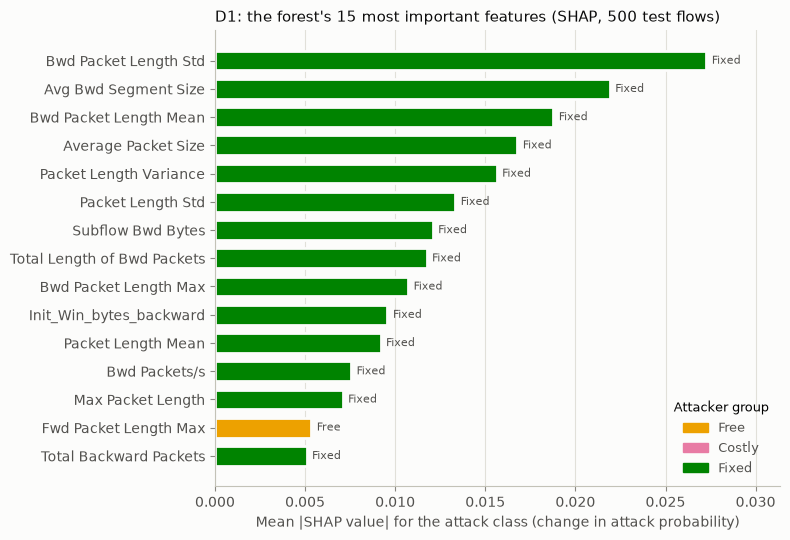

In [35]:
# STEP D1
# Figure: the SHAP top 15, bars coloured by attacker group, with the group also written next to
# each bar (two of the colours are light, so colour never carries the group alone).
GROUP_COLORS = {"Free": "#eda100", "Costly": "#e87ba4", "Fixed": "#008300"}
top15 = shap_rank.head(15)[::-1]

fig, ax = plt.subplots(figsize=(8, 5.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for side_ in ("top", "right"):
    ax.spines[side_].set_visible(False)
for side_ in ("left", "bottom"):
    ax.spines[side_].set_color(AXIS)
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.barh(top15.index, top15.to_numpy(), color=[GROUP_COLORS[GROUP[f]] for f in top15.index],
        height=0.7, edgecolor=SURFACE, linewidth=2)
for y, f in enumerate(top15.index):
    ax.annotate(GROUP[f], xy=(top15[f], y), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=8, color=INK_2)
ax.set_xlim(0, top15.max() * 1.15)
ax.tick_params(colors=MUTED, labelcolor=INK_2)
ax.set_xlabel("Mean |SHAP value| for the attack class (change in attack probability)", color=INK_2)
handles = [plt.Rectangle((0, 0), 1, 1, color=GROUP_COLORS[g]) for g in GROUP_COLORS]
ax.legend(handles, list(GROUP_COLORS), title="Attacker group", frameon=False, loc="lower right",
          labelcolor=INK_2, title_fontsize=9, fontsize=9)
ax.set_title("D1: the forest's 15 most important features (SHAP, 500 test flows)", color=INK,
             loc="left", fontsize=11)
fig.tight_layout()
fig.savefig("results/figures/D1_shap_bar.png", dpi=150, facecolor=SURFACE)
plt.show()

<!-- STEP D1 -->
**What we found.** All ten of SHAP's most important features are **Fixed**, and Fixed features carry
77% of the total mean |SHAP| (Free 17%, Costly 5%). The overlap between SHAP's top ten and the
attacker's lists is **zero**: zero with the ten features the attack tried most, zero with the nine
features used in the successful evasions.

| SHAP rank | SHAP top 10 (all Fixed) | Attacker tried most (C3) | Group |
|---|---|---|---|
| 1 | Bwd Packet Length Std | Subflow Fwd Packets | Costly |
| 2 | Avg Bwd Segment Size | Total Length of Fwd Packets | Costly |
| 3 | Bwd Packet Length Mean | Fwd Packet Length Max | Free |
| 4 | Average Packet Size | Fwd Header Length | Free |
| 5 | Packet Length Variance | Total Fwd Packets | Costly |
| 6 | Packet Length Std | Subflow Fwd Bytes | Costly |
| 7 | Subflow Bwd Bytes | Fwd IAT Min | Free |
| 8 | Total Length of Bwd Packets | Flow IAT Min | Free |
| 9 | Bwd Packet Length Max | Active Std | Free |
| 10 | Init_Win_bytes_backward | Fwd IAT Std | Free |

**Check yourself: are the model's most important features ones the attacker can change?** No. The
forest decides mainly on the size of the **victim's replies** (`Bwd Packet Length …`, `Avg Bwd
Segment Size`) and on packet-size statistics that mix both directions. An attacker cannot forge
those, which is why the constrained attack in C2 stayed below 20% while the unconstrained attack,
which *could* edit the victim's replies (87% of its steps did), evaded everything. That is good news
for the defender, with two caveats:

- **The protection comes from the network, not the model.** If the attacker controls the other end
  too (a compromised server), the most important evidence becomes forgeable at once.
- **Twins can leak control.** `Subflow Bwd Bytes` and `Total Length of Bwd Packets` (SHAP ranks 7
  and 8) are twins (|corr| > 0.95) of the Costly `Total Fwd Packets`, `Subflow Fwd Packets` and
  `act_data_pkt_fwd`: in real traffic, more requests from the attacker usually mean more reply bytes
  from the victim. Our attack moves features one at a time, so it never exploits this. A real
  attacker might, so these two "Fixed" features are less safe than their label says.

**Check yourself: a feature used often by the attack but ranked low by SHAP, what could explain
that?** The two features behind all seven DDoS evasions, `Fwd IAT Min` and `Flow IAT Min`, rank only
41st and 58th of 68 in SHAP. Three reasons fit:

1. **SHAP ranks the average, the attacker exploits single flows.** Mean |SHAP| over 500 mostly benign
   flows says how much a feature matters *typically*. The attacker only needs a feature that matters
   for one flow already near the boundary, and for a few DDoS flows the minimum gap is exactly that.
2. **Big steps move a flow into regions the model rarely sees.** +4.8 s on the shortest gap is a
   value no ordinary flow has, so its contribution on the 500 explained flows says little about what
   happens there.
3. **The attack moves one feature but SHAP splits credit among twins.** Changes the attack tried
   often (forward counts) have Fixed twins that SHAP gives the credit to.

So a SHAP ranking is a poor guide to *where* an attacker will push: it describes what the model
relies on for typical flows, not where its decision boundary is thinnest.

<!-- STEP D2 -->
### Step D2: Is the explanation stable under noise?

**Stable** means: run the explainer on almost the same input and get almost the same answer. We
explain the same 200 test flows (the first 200 of `EXPLAIN_IDX`, a subset of D1's 500) twice with
TreeSHAP, once clean and once with B1's 5% noise. For each run we rank the features by mean |SHAP|
for the attack class, and compare the two rankings with the **Spearman rank correlation** (1 = same
order, 0 = unrelated). Above 0.90 counts as stable.

Stable is not the same as *faithful* (lab section 3.5): an explanation can be perfectly stable and
still describe the wrong thing. Part F tests faithfulness.

B1 showed that 5% noise already makes the forest call almost every attack benign, so we also run two
much smaller levels (0.1% and 1%) for context. They let us tell apart "SHAP is unstable" from "the
model itself decided differently".

In [36]:
# STEP D2
import shap
from scipy.stats import spearmanr

d2_flows = X_test.iloc[EXPLAIN_IDX[:200]]
d2_y = y_test.iloc[EXPLAIN_IDX[:200]]
d2_explainer = shap.TreeExplainer(rf)


def attack_shap(X):
    """SHAP values for the attack class: one row per flow, one column per feature."""
    return d2_explainer(X).values[:, :, 1]


def ranking(values, rows=None):
    """Mean |SHAP| per feature over the given rows (all rows by default)."""
    v = values if rows is None else values[rows]
    return pd.Series(np.abs(v).mean(axis=0), index=FEATURES)


start = time.time()
d2_levels = [0.001, 0.01, 0.05]
shap_clean = attack_shap(d2_flows)
shap_noisy = {level: attack_shap(add_noise(d2_flows, X_train, level)) for level in d2_levels}
rank_clean = ranking(shap_clean)
d2_rankings = {level: ranking(v) for level, v in shap_noisy.items()}
print(f"{len(d2_flows)} flows ({int(d2_y.sum())} attacks), SHAP 4 times in {time.time() - start:.0f} s")

200 flows (24 attacks), SHAP 4 times in 212 s


In [37]:
# STEP D2
rows = []
pred_clean = rf.predict(d2_flows)
for level, rank_noisy in d2_rankings.items():
    rho, _ = spearmanr(rank_clean, rank_noisy)
    top10_overlap = len(set(rank_clean.nlargest(10).index) & set(rank_noisy.nlargest(10).index))
    pred_noisy = rf.predict(add_noise(d2_flows, X_train, level))
    rows.append({"noise level": level, "spearman": rho, "top-10 overlap": top10_overlap,
                 "top-5 identical": list(rank_clean.nlargest(5).index) == list(rank_noisy.nlargest(5).index),
                 "flows whose prediction changed": int((pred_clean != pred_noisy).sum()),
                 "attacks still detected": f"{int(pred_noisy[d2_y.to_numpy() == 1].sum())} of {int(d2_y.sum())}"})
d2_summary = pd.DataFrame(rows).set_index("noise level")
d2_summary.to_csv("results/tables/D2_stability_by_level.csv", float_format="%.4f")
d2_summary.round(4)

,spearman,top-10 overlap,top-5 identical,flows whose prediction changed,attacks still detected
noise level,,,,,
0.001,0.9071,9,False,5,19 of 24
0.010,0.9048,7,False,19,5 of 24
0.050,0.8991,7,False,23,1 of 24


In [38]:
# STEP D2
# The lab's comparison: clean vs 5% noise, both top-5 lists and the full rankings.
rank_noisy5 = d2_rankings[0.05]
rho5, _ = spearmanr(rank_clean, rank_noisy5)
print(f"Spearman rank correlation, clean vs 5% noise: {rho5:.3f}  "
      f"({'stable' if rho5 > 0.90 else 'NOT stable'} by the lab's 0.90 rule)\n")
top5 = pd.DataFrame({"clean": rank_clean.nlargest(5).index,
                     "5% noise": rank_noisy5.nlargest(5).index}, index=range(1, 6))
print(top5.to_string())

d2_table = pd.DataFrame({
    "mean_abs_shap_clean": rank_clean, "mean_abs_shap_noisy5": rank_noisy5,
    "rank_clean": rank_clean.rank(ascending=False).astype(int),
    "rank_noisy5": rank_noisy5.rank(ascending=False).astype(int),
}).sort_values("rank_clean")
d2_table.index.name = "feature"
d2_table.to_csv("results/tables/D2_shap_stability.csv", float_format="%.5f")
print(f"\nTotal mean |SHAP|: clean {rank_clean.sum():.3f}, 5% noise {rank_noisy5.sum():.3f}")

Spearman rank correlation, clean vs 5% noise: 0.899  (NOT stable by the lab's 0.90 rule)

                    clean               5% noise
1   Bwd Packet Length Std  Bwd Packet Length Std
2    Avg Bwd Segment Size          Bwd Packets/s
3  Bwd Packet Length Mean   Avg Bwd Segment Size
4     Average Packet Size    Average Packet Size
5  Packet Length Variance      Bwd Header Length

Total mean |SHAP|: clean 0.274, 5% noise 0.328


In [39]:
# STEP D2
# Two reasons the overall correlation can hide change: most of the 200 flows are benign, and most of
# the 68 features have near-zero SHAP, so their order reshuffles at any noise level.
is_attack = d2_y.to_numpy() == 1
top20 = rank_clean.nlargest(20).index
rows = []
for level in d2_levels:
    noisy = shap_noisy[level]
    rows.append({
        "noise level": level,
        "all 200 flows, 68 features": spearmanr(rank_clean, d2_rankings[level])[0],
        "all 200 flows, clean top-20 features": spearmanr(rank_clean[top20], d2_rankings[level][top20])[0],
        "24 attacks only, 68 features": spearmanr(ranking(shap_clean, is_attack), ranking(noisy, is_attack))[0],
        "176 benign only, 68 features": spearmanr(ranking(shap_clean, ~is_attack), ranking(noisy, ~is_attack))[0],
        "attacks: mean SHAP sum (clean -> noisy)":
            f"{shap_clean[is_attack].sum(axis=1).mean():+.3f} -> {noisy[is_attack].sum(axis=1).mean():+.3f}",
    })
d2_split = pd.DataFrame(rows).set_index("noise level")
d2_split.to_csv("results/tables/D2_stability_split.csv", float_format="%.4f")
print("Attack-flow top 5, clean vs 5% noise:")
print(pd.DataFrame({"clean": ranking(shap_clean, is_attack).nlargest(5).index,
                    "5% noise": ranking(shap_noisy[0.05], is_attack).nlargest(5).index},
                   index=range(1, 6)).to_string())
d2_split.round(3)

Attack-flow top 5, clean vs 5% noise:
                    clean                     5% noise
1   Bwd Packet Length Std        Bwd Packet Length Std
2    Avg Bwd Segment Size            Subflow Bwd Bytes
3  Packet Length Variance  Total Length of Bwd Packets
4  Bwd Packet Length Mean       Packet Length Variance
5       Packet Length Std         Avg Bwd Segment Size


,"all 200 flows, 68 features","all 200 flows, clean top-20 features","24 attacks only, 68 features","176 benign only, 68 features",attacks: mean SHAP sum (clean -> noisy)
noise level,,,,,
0.001,0.907,0.908,0.958,0.863,+0.842 -> +0.492
0.010,0.905,0.669,0.948,0.835,+0.842 -> +0.274
0.050,0.899,0.496,0.949,0.830,+0.842 -> +0.216


<!-- STEP D2 -->
**What we found.** By the lab's test the SHAP ranking is right at the border: the Spearman correlation
between the clean and the 5%-noise ranking (68 features, 200 flows) is **0.899**, just under 0.90. The
top-ranked feature stays the same (`Bwd Packet Length Std`), and 3 of the top 5 survive.

| Noise | Spearman, 68 features | Spearman, top-20 features | Spearman, attacks only | Attacks still detected |
|---|---|---|---|---|
| 0.1% | 0.907 | 0.908 | 0.958 | 19 of 24 |
| 1% | 0.905 | 0.669 | 0.948 | 5 of 24 |
| 5% | 0.899 | **0.496** | 0.949 | **1 of 24** |

That single number hides two things.

1. **The important part of the ranking is not stable.** Over the 20 features that carry most of the
   SHAP weight, the correlation falls to 0.67 at 1% noise and 0.50 at 5%. The 68-feature number stays
   near 0.90 only because most features have almost no SHAP weight and stay at the bottom of both
   rankings, so their agreement props up the overall correlation. A ranking can look "stable" mainly
   because the unimportant features stay unimportant.
2. **A stable ranking can hide a flipped decision.** For the 24 attacks the ranking hardly changes
   (0.95 at every level): the explanation keeps naming the same features (`Bwd Packet Length Std`,
   `Avg Bwd Segment Size`, `Packet Length Variance`). But the total push those features give towards
   "attack" falls from +0.84 to +0.22, and the forest now calls 23 of the 24 attacks benign. An
   analyst who only looked at the ranking would see the same explanation for a decision that has
   reversed.

So the SHAP explanation is stable in the narrow sense the lab measures (borderline at 5%), but that
stability says nothing about whether the explanation, or the model, is right. This is lab section
3.5's warning in practice: stable is not the same as faithful. Part F tests faithfulness directly.
The 200 flows are a subset of D1's 500 (24 attacks); their clean ranking has the same leader as
D1's.

<!-- STEP E1 -->
## Part E: Two defences

### Step E1: An ensemble

If one model is fooled by a change, a model with a different decision boundary may not be. We add a
**gradient boosting** model (200 trees of depth 4) and average the attack probabilities of three
models with very different boundaries: the random forest (deep trees, voting), gradient boosting
(shallow trees, built one after another) and logistic regression (one straight boundary).

**Training data.** Gradient boosting trains on one core and is slow on all 267,984 training rows, so
it is trained on a **stratified 100,000-row subsample** of the training set (seed 42), as the lab
allows. The forest and logistic regression are the ones from the setup, trained on the full set.

We compare the forest and the ensemble on clean data, 5% noise (B1), 10% missing values (B2) and the
constrained attack (C2). For the attack row we attack the **ensemble itself**, because a real attacker
probes the system that is actually deployed.

In [40]:
# STEP E1
from sklearn.ensemble import GradientBoostingClassifier

GB_PATH = MODEL_DIR / "gb.joblib"
gb = joblib.load(GB_PATH) if GB_PATH.is_file() else None
if gb is None or list(getattr(gb, "feature_names_in_", [])) != FEATURES:
    # Stratified on the attack type, like every split in this lab, so all attack families appear.
    gb_rows, _ = train_test_split(np.arange(len(X_train)), train_size=100_000,
                                  stratify=type_train, random_state=SEED)
    start = time.time()
    gb = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=SEED)
    gb.fit(X_train.iloc[gb_rows], y_train.iloc[gb_rows])
    joblib.dump(gb, GB_PATH)
    print(f"gradient boosting trained on {len(gb_rows):,} rows in {time.time() - start:.0f} s")
else:
    print(f"gradient boosting loaded from {GB_PATH}")


class AvgEnsemble:
    """Average of the members' attack probabilities. Works with report() and greedy_attack()."""

    def __init__(self, models):
        self.models = models
        self.classes_ = np.array([0, 1])

    def predict_proba(self, X):
        return np.mean([m.predict_proba(X) for m in self.models], axis=0)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


ensemble = AvgEnsemble([rf, gb, logreg])

gradient boosting trained on 100,000 rows in 411 s


In [41]:
# STEP E1
# Clean, 5% noise and 10% missing values: the same damaged test sets as in B1 and B2.
conditions = {
    "clean": X_test,
    "5% noise": add_noise(X_test, X_train, 0.05),
    "10% missing": add_missing(X_test, 0.10),
}
scored = {"forest": rf, "ensemble": ensemble, "gradient boosting": gb}
e1_rows = [{"condition": cond, "model": name, **report(model, Xc, y_test)}
           for cond, Xc in conditions.items() for name, model in scored.items()]
e1_scores = pd.DataFrame(e1_rows)
print(e1_scores.pivot(index="condition", columns="model", values="macro_f1")
      .loc[list(conditions)].round(4).to_string())
print()
print(e1_scores.pivot(index="condition", columns="model", values="recall")
      .loc[list(conditions)].round(4).to_string())

model        ensemble  forest  gradient boosting
condition                                       
clean          0.9965  0.9968             0.9962
5% noise       0.6205  0.5212             0.5007
10% missing    0.9725  0.9900             0.9421

model        ensemble  forest  gradient boosting
condition                                       
clean          0.9895  0.9923             0.9905
5% noise       0.1926  0.0633             0.1024
10% missing    0.9133  0.9681             0.8383


In [42]:
# STEP E1
# The constrained attack (C2) against the ensemble itself, on the same 50 flows.
start = time.time()
ens_rows, ens_adv = [], []
for pos in ATTACK_IDX:
    result = greedy_attack(ensemble, X_test.iloc[[pos]], constrained=True)
    ens_adv.append(result["x_adv"])
    ens_rows.append({"test_position": int(pos), "attack_type": type_test.iloc[pos],
                     "p_before": result["p_before"], "p_after": result["p_after"],
                     "evaded": result["p_after"] < 0.5,
                     "n_features_changed": len(set(result["changed"])),
                     "changed": ";".join(result["changed"])})
ensemble_attack = pd.DataFrame(ens_rows)
ensemble_adv = pd.concat(ens_adv)                   # the edited rows, in ATTACK_IDX order
print(f"attack on the ensemble: {time.time() - start:.0f} s")

already_missed = int((ensemble_attack["p_before"] < 0.5).sum())
print(f"Flows the ensemble already called benign before any change: {already_missed} of 50")
print(f"Ensemble p_before on the 50 flows: min {ensemble_attack['p_before'].min():.3f}, "
      f"mean {ensemble_attack['p_before'].mean():.3f}")

attack on the ensemble: 27 s
Flows the ensemble already called benign before any change: 0 of 50
Ensemble p_before on the 50 flows: min 0.701, mean 0.959


In [43]:
# STEP E1
forest_attack = attack_runs["constrained"]
attack_summary = pd.DataFrame({
    name: {"evaded (of 50)": int(df["evaded"].sum()),
           "already benign before the attack": int((df["p_before"] < 0.5).sum()),
           "mean p before": df["p_before"].mean(),
           "mean p after": df["p_after"].mean(),
           "mean features changed": df["n_features_changed"].mean()}
    for name, df in (("forest", forest_attack), ("ensemble", ensemble_attack))}).T

# The four-row comparison the lab asks for: macro-F1 and recall for clean / noise / missing,
# evaded-of-50 and mean probability after for the attack.
e1_table = pd.DataFrame({
    name: {
        **{f"{cond} macro-F1": e1_scores.query("condition == @cond and model == @name")["macro_f1"].item()
           for cond in conditions},
        **{f"{cond} recall": e1_scores.query("condition == @cond and model == @name")["recall"].item()
           for cond in conditions},
        "attack: evaded of 50": attack_summary.loc[name, "evaded (of 50)"],
        "attack: mean p after": attack_summary.loc[name, "mean p after"],
    } for name in ("forest", "ensemble")}).T
e1_table.to_csv("results/tables/E1_ensemble.csv", float_format="%.4f")
e1_scores.to_csv("results/tables/E1_scores_all.csv", index=False, float_format="%.4f")
ensemble_attack.to_csv("results/tables/E1_ensemble_attack_per_flow.csv", index=False, float_format="%.4f")
print(attack_summary.round(3).to_string())
e1_table.T.round(4)

          evaded (of 50)  already benign before the attack  mean p before  mean p after  mean features changed
forest               9.0                               0.0          1.000         0.731                   4.22
ensemble            11.0                               0.0          0.959         0.725                   3.94


,forest,ensemble
clean macro-F1,0.9968,0.9965
5% noise macro-F1,0.5212,0.6205
10% missing macro-F1,0.9900,0.9725
clean recall,0.9923,0.9895
5% noise recall,0.0633,0.1926
10% missing recall,0.9681,0.9133
attack: evaded of 50,9.0000,11.0000
attack: mean p after,0.7311,0.7246


In [44]:
# STEP E1
# Which members drive the ensemble under noise and under the attack?
members = {"forest": rf, "gradient boosting": gb, "logreg": logreg}
noisy = conditions["5% noise"]
attacks = y_test.to_numpy() == 1
print("Mean attack probability on real attacks, 5% noise:")
for name, m in members.items():
    print(f"  {name:<18} {m.predict_proba(noisy)[attacks, 1].mean():.3f}")

adv = ensemble_adv[ensemble_attack["evaded"].to_numpy()]
if len(adv):
    print("\nMember probabilities on the flows that evaded the ensemble:")
    member_p = pd.DataFrame({name: m.predict_proba(adv)[:, 1] for name, m in members.items()},
                            index=ensemble_attack.loc[ensemble_attack["evaded"], "attack_type"])
    print(member_p.round(3).to_string())
    before = pd.DataFrame({name: m.predict_proba(X_test.iloc[ATTACK_IDX[ensemble_attack["evaded"].to_numpy()]])[:, 1]
                           for name, m in members.items()})
    print("\nThe same flows before the attack (mean):", before.mean().round(3).to_dict())

Mean attack probability on real attacks, 5% noise:


  forest             0.357


  gradient boosting  0.122


  logreg             0.838

Member probabilities on the flows that evaded the ensemble:
               forest  gradient boosting  logreg
attack_type                                     
DoS GoldenEye   0.850              0.422   0.001
SSH-Patator     0.857              0.615   0.000
DDoS            0.737              0.538   0.054
DoS Hulk        0.683              0.790   0.017
DoS GoldenEye   0.833              0.422   0.001
DDoS            0.580              0.424   0.162
DDoS            0.740              0.648   0.062
DDoS            0.580              0.492   0.171
DDoS            0.573              0.416   0.166
DDoS            0.740              0.693   0.063
DDoS            0.637              0.481   0.329



The same flows before the attack (mean): {'forest': 1.0, 'gradient boosting': 0.987, 'logreg': 0.458}


In [45]:
# STEP E1
# Latency: how long does one decision take? An IDS answers per flow, often one at a time.
one_flow = X_test.iloc[[0]]
batch = X_test.iloc[:10_000]
latency = {}
for name, m in {"forest": rf, "gradient boosting": gb, "logreg": logreg, "ensemble": ensemble}.items():
    m.predict_proba(one_flow)                                    # warm-up
    t = time.perf_counter()
    for _ in range(20):
        m.predict_proba(one_flow)
    single_ms = (time.perf_counter() - t) / 20 * 1000
    t = time.perf_counter()
    m.predict_proba(batch)
    per_flow_us = (time.perf_counter() - t) / len(batch) * 1e6
    latency[name] = {"one flow (ms)": single_ms, "per flow in a batch of 10,000 (µs)": per_flow_us}
latency = pd.DataFrame(latency).T
latency.to_csv("results/tables/E1_latency.csv", float_format="%.3f")
latency.round(3)

,one flow (ms),"per flow in a batch of 10,000 (µs)"
forest,84.042,18.756
gradient boosting,2.706,7.333
logreg,3.061,3.216
ensemble,94.498,29.161


<!-- STEP E1 -->
**What we found.**

| | Forest | Ensemble (forest + GB + logreg) |
|---|---|---|
| Clean macro-F1 / recall | 0.997 / 0.992 | 0.997 / 0.990 |
| 5% noise macro-F1 / recall | 0.521 / 0.063 | **0.621 / 0.193** |
| 10% missing macro-F1 / recall | **0.990 / 0.968** | 0.973 / 0.913 |
| Constrained attack: evaded of 50 | **9** | 11 |
| Constrained attack: mean p after | 0.731 | 0.725 |

The ensemble is as good as the forest on clean data, a little better under noise, a little worse with
missing values, and **slightly easier to evade** (11 of 50 instead of 9). Gradient boosting was trained
on a stratified 100,000-row subsample of the training set (seed 42) to keep its training time at about
7 minutes; the forest and logistic regression use the full training set.

**Check yourself: did the ensemble help more against noise or against the attack, and why might those
differ?** Against noise, but only a little, and only thanks to logistic regression: under 5% noise the
forest gives real attacks an average probability of 0.36 and gradient boosting 0.12, while logistic
regression keeps 0.84 (B1 showed why: it reads features in units of their standard deviation). The
average of the three is pulled above 0.5 for some attacks, so recall rises from 0.06 to 0.19.

Against the attack the ensemble did *not* help, for the opposite reason. On the 11 flows that evaded
the ensemble, the forest alone still says "attack" (0.57–0.86), but logistic regression ends near 0
(at most 0.33). It was already unsure about exactly these flows before any change (mean 0.46, against
1.00 for the forest and 0.99 for gradient boosting), and a few extra packets and bytes push its linear
score the rest of the way. An average gives every member the same say, so the member that is easiest
to fool drags the ensemble under 0.5, and the attack automatically finds the flows where it is weak. The two kinds of damage differ in a basic way: noise is **random**, so independent errors
of different models partly cancel out in an average; the attacker is **adaptive**, probes the
ensemble itself and pushes on its weakest member. An ensemble only helps against an attacker if every
member is hard to fool, or if it combines members with a rule an attacker cannot exploit (for example
"alert if any member is confident").

**Check yourself: is running three models affordable in an IDS that answers in milliseconds?** On
this machine one flow takes about 90 ms with the forest alone and about the same with the ensemble
(the exact numbers vary by a few ms between runs); most of that is the overhead of spreading 300 trees
over 8 cores, not the models themselves. In batches of 10,000 flows the cost is about 20 µs per flow
for the forest and 30 µs for the ensemble (gradient boosting 8 µs, logistic regression 4 µs). So the
extra two models cost little; the forest is the expensive part. At line rate an IDS scores flows in
batches, where about 30 µs per flow is roughly 30,000 flows per second per machine, which is affordable for many networks but not for a busy backbone. Given that the
ensemble did not make the attack harder, the extra cost buys only the small gain under noise.

<!-- STEP E2 -->
### Step E2: Drop one feature, then drop a whole group

"Which features can we stop collecting?" is usually answered by removing one feature at a time and
retraining. With twin features (lab section 3.6) that answer is misleading: when one feature is
removed, its twin takes over. So we do it both ways.

- **Same data in every run (graded):** one fixed stratified sample of **30,000 training rows** (seed 42,
  stratified on the attack type), and the full test set for scoring.
- **Model:** a 100-tree forest with the same settings as the main forest (`max_depth=20`,
  `random_state=42`), retrained for every removal.
- **Single:** 68 runs, each without one feature. **Group:** one run per correlation group (features
  linked by |corr| > 0.95 directly or through a chain, at least 2 members), without the whole group.
- **Noise band:** the reference forest trained with 5 different seeds, to see how much macro-F1 moves
  from training randomness alone. A removal whose drop is inside that band has no measurable effect.

In [46]:
# STEP E2
from scipy.sparse.csgraph import connected_components

e2_rows_idx, _ = train_test_split(np.arange(len(X_train)), train_size=30_000,
                                  stratify=type_train, random_state=SEED)
X_e2, y_e2 = X_train.iloc[e2_rows_idx], y_train.iloc[e2_rows_idx]
print(f"Fixed training sample: {len(X_e2):,} rows, attack rate {y_e2.mean():.4f}; "
      f"scored on all {len(X_test):,} test rows")


def forest_score(columns, seed=SEED):
    """Train a 100-tree forest on the fixed sample using only `columns`; test macro-F1 and recall."""
    model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=seed, n_jobs=-1)
    model.fit(X_e2[columns], y_e2)
    pred = model.predict(X_test[columns])
    return f1_score(y_test, pred, average="macro"), recall_score(y_test, pred)


start = time.time()
ref_f1, ref_recall = forest_score(FEATURES)
noise_band = [forest_score(FEATURES, seed=s)[0] for s in (1, 2, 3, 4, 5)]
band = max(noise_band + [ref_f1]) - min(noise_band + [ref_f1])
print(f"Reference (all 68 features): macro-F1 {ref_f1:.4f}, recall {ref_recall:.4f}")
print(f"Same forest with 6 different seeds: macro-F1 {min(noise_band + [ref_f1]):.4f}-"
      f"{max(noise_band + [ref_f1]):.4f} (band {band:.4f})   [{time.time() - start:.0f} s]")

Fixed training sample: 30,000 rows, attack rate 0.1507; scored on all 89,329 test rows


Reference (all 68 features): macro-F1 0.9941, recall 0.9859
Same forest with 6 different seeds: macro-F1 0.9936-0.9944 (band 0.0008)   [21 s]


In [47]:
# STEP E2
start = time.time()
single_rows = []
for f in FEATURES:
    f1_, rec_ = forest_score([c for c in FEATURES if c != f])
    single_rows.append({"feature": f, "macro_f1": f1_, "recall": rec_,
                        "macro_f1_drop": ref_f1 - f1_, "recall_drop": ref_recall - rec_})
e2_single = pd.DataFrame(single_rows).set_index("feature").sort_values("macro_f1_drop", ascending=False)
e2_single["outside_noise_band"] = e2_single["macro_f1_drop"].abs() > band
e2_single.to_csv("results/tables/E2_single_removal.csv", float_format="%.5f")
print(f"68 single removals in {time.time() - start:.0f} s")
print(f"Removals with a macro-F1 drop larger than the noise band ({band:.4f}): "
      f"{int((e2_single['macro_f1_drop'] > band).sum())} of 68")
print("\nThe five removals that cost most:")
print(e2_single.head(5)[["macro_f1", "macro_f1_drop", "recall_drop"]].round(4).to_string())

68 single removals in 242 s
Removals with a macro-F1 drop larger than the noise band (0.0008): 2 of 68

The five removals that cost most:
                             macro_f1  macro_f1_drop  recall_drop
feature                                                          
Fwd IAT Min                    0.9928         0.0013       0.0043
Init_Win_bytes_forward         0.9930         0.0011       0.0016
Bwd Header Length              0.9934         0.0007       0.0019
Flow Bytes/s                   0.9937         0.0005       0.0016
Total Length of Fwd Packets    0.9937         0.0004       0.0013


In [48]:
# STEP E2
linked = (CORR > 0.95).to_numpy(copy=True)          # pandas 3 may return a read-only view
np.fill_diagonal(linked, False)
_, comp = connected_components(linked, directed=False)
comp = pd.Series(comp, index=FEATURES)
e2_groups = [list(comp.index[comp == g]) for g in dict.fromkeys(comp)
             if (comp == g).sum() >= 2]
print(f"{len(e2_groups)} correlation groups with 2 or more features, covering "
      f"{sum(len(g) for g in e2_groups)} features")

start = time.time()
group_rows = []
for members in e2_groups:
    f1_, rec_ = forest_score([c for c in FEATURES if c not in members])
    singles = e2_single.loc[members, "macro_f1_drop"]
    group_rows.append({"group": f"{members[0]} (+{len(members) - 1})", "size": len(members),
                       "members": "; ".join(members),
                       "macro_f1": f1_, "macro_f1_drop": ref_f1 - f1_, "recall_drop": ref_recall - rec_,
                       "largest_single_drop": singles.max(), "sum_of_single_drops": singles.sum()})
e2_group = pd.DataFrame(group_rows).set_index("group").sort_values("macro_f1_drop", ascending=False)
e2_group.to_csv("results/tables/E2_group_removal.csv", float_format="%.5f")
print(f"{len(e2_groups)} group removals in {time.time() - start:.0f} s\n")
print(e2_group[["size", "macro_f1_drop", "largest_single_drop", "sum_of_single_drops", "recall_drop"]]
      .round(4).to_string())

14 correlation groups with 2 or more features, covering 39 features


14 group removals in 50 s

                                  size  macro_f1_drop  largest_single_drop  sum_of_single_drops  recall_drop
group                                                                                                       
Flow IAT Max (+4)                    5         0.0006               0.0003               0.0008       0.0017
Bwd Packet Length Max (+3)           4         0.0004               0.0004               0.0013       0.0014
Total Fwd Packets (+6)               7         0.0004               0.0003               0.0010       0.0013
Fwd Packet Length Max (+1)           2         0.0004               0.0004               0.0005       0.0013
Packet Length Mean (+1)              2         0.0003               0.0003               0.0006       0.0012
Fwd Packet Length Mean (+1)          2         0.0002               0.0004               0.0007       0.0007
RST Flag Count (+1)                  2         0.0002               0.0002               0.0002      

In [49]:
# STEP E2
# How much has to go before it hurts? Retrain without whole functional blocks of features, and
# without the largest groups found at looser correlation thresholds.
blocks = {
    "all backward features": [f for f in FEATURES if "Bwd" in f or "backward" in f.lower()],
    "all forward features": [f for f in FEATURES if ("Fwd" in f or "forward" in f.lower())
                             and not ("Bwd" in f or "backward" in f.lower())],
    "all timing features": [f for f in FEATURES if any(k in f for k in ("IAT", "Idle", "Active", "Duration"))],
    "all size features": [f for f in FEATURES if any(k in f for k in ("Length", "Size", "Bytes", "Variance"))
                          and "/s" not in f and "Header" not in f],
    "all flag features": list(FLAG_COLS),
}
for threshold in (0.90, 0.80):
    links = (CORR > threshold).to_numpy(copy=True)
    np.fill_diagonal(links, False)
    _, comp_t = connected_components(links, directed=False)
    sizes = pd.Series(comp_t).value_counts()
    largest = sizes.index[0]
    blocks[f"largest |corr| > {threshold:.2f} group"] = [FEATURES[j] for j in np.flatnonzero(comp_t == largest)]

start = time.time()
block_rows = []
for name, cols in blocks.items():
    f1_, rec_ = forest_score([c for c in FEATURES if c not in cols])
    block_rows.append({"removed": name, "features_removed": len(cols), "macro_f1": f1_,
                       "macro_f1_drop": ref_f1 - f1_, "recall_drop": ref_recall - rec_,
                       "members": "; ".join(cols)})
e2_blocks = pd.DataFrame(block_rows).set_index("removed")
e2_blocks.to_csv("results/tables/E2_block_removal.csv", float_format="%.5f")
print(f"{len(blocks)} block removals in {time.time() - start:.0f} s (noise band {band:.4f})")
e2_blocks.drop(columns="members").round(4)


7 block removals in 21 s (noise band 0.0008)


,features_removed,macro_f1,macro_f1_drop,recall_drop
removed,,,,
all backward features,17,0.9927,0.0015,0.0040
all forward features,20,0.9916,0.0025,0.0063
all timing features,23,0.9934,0.0008,0.0022
all size features,20,0.9921,0.0020,0.0062
all flag features,10,0.9939,0.0002,0.0002
largest |corr| > 0.90 group,9,0.9932,0.0009,0.0028
largest |corr| > 0.80 group,12,0.9939,0.0002,0.0017


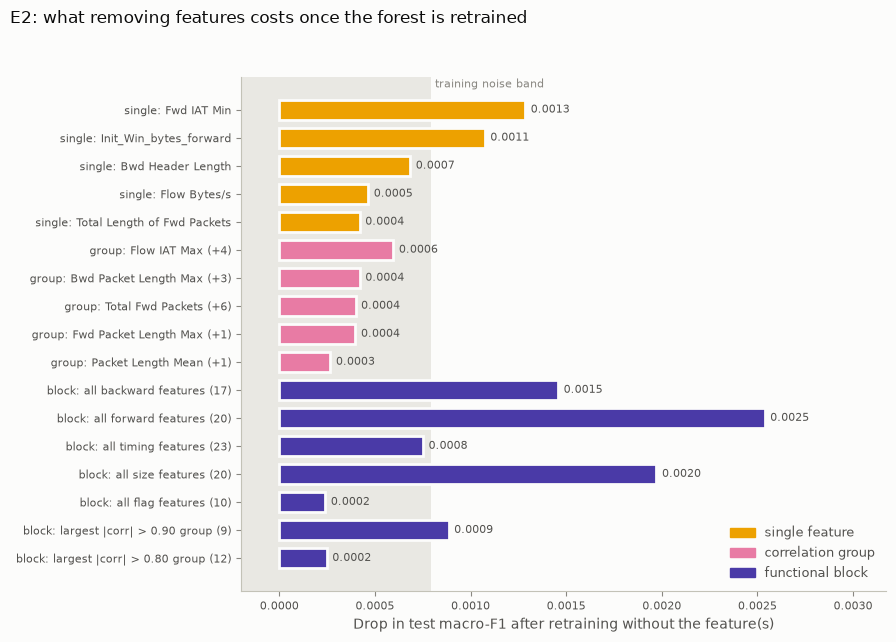

In [50]:
# STEP E2
# Figure: the cost of the largest single removals, the largest group removals and whole blocks, on one
# axis with the training-noise band. Kind is written in each label and every bar carries its value,
# so colour never carries the meaning alone.
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
KIND_COLORS = {"single feature": "#eda100", "correlation group": "#e87ba4", "functional block": "#4a3aa7"}
bars = pd.concat([
    pd.DataFrame({"label": [f"single: {f}" for f in e2_single.index[:5]],
                  "drop": e2_single["macro_f1_drop"].iloc[:5].to_numpy(), "kind": "single feature"}),
    pd.DataFrame({"label": [f"group: {g}" for g in e2_group.index[:5]],
                  "drop": e2_group["macro_f1_drop"].iloc[:5].to_numpy(), "kind": "correlation group"}),
    pd.DataFrame({"label": [f"block: {b} ({n})" for b, n in e2_blocks["features_removed"].items()],
                  "drop": e2_blocks["macro_f1_drop"].to_numpy(), "kind": "functional block"}),
]).iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 6.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(AXIS)
ax.axvspan(-band, band, color=GRID, alpha=0.7, linewidth=0)
ax.text(band, len(bars) - 0.3, " training noise band", color=MUTED, fontsize=8, va="bottom")
ax.barh(bars.index, bars["drop"], color=bars["kind"].map(KIND_COLORS), height=0.7,
        edgecolor=SURFACE, linewidth=2)
for y, d in zip(bars.index, bars["drop"]):
    ax.annotate(f"{d:.4f}", (max(d, 0), y), xytext=(4, 0), textcoords="offset points", va="center",
                fontsize=8, color=INK_2)
ax.set_yticks(bars.index, bars["label"])
ax.tick_params(colors=MUTED, labelcolor=INK_2, labelsize=8)
ax.set_xlim(min(0, bars["drop"].min()) - 0.0002, bars["drop"].max() * 1.25)
ax.set_xlabel("Drop in test macro-F1 after retraining without the feature(s)", color=INK_2)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in KIND_COLORS.values()]
ax.legend(handles, list(KIND_COLORS), loc="lower right", frameon=False, labelcolor=INK_2, fontsize=9)
fig.suptitle("E2: what removing features costs once the forest is retrained", color=INK, x=0.01,
             ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig("results/figures/E2_single_vs_group.png", dpi=150, facecolor=SURFACE)
plt.show()

<!-- STEP E2 -->
**What we found.** Training randomness alone moves the macro-F1 of this forest by **0.0008** (6 seeds,
0.9936–0.9944), so smaller differences mean nothing.

- **Single removals look free**, as the lab expects: only 2 of the 68 cost more than the noise band,
  and the largest drop is 0.0013 (`Fwd IAT Min`), then 0.0011 (`Init_Win_bytes_forward`).
- **Group removals also look free**, which the lab does *not* expect: removing any of the 14
  correlation groups costs at most 0.0006, inside the noise band. Even SHAP's top family
  (`Bwd Packet Length Max/Mean/Std`, `Avg Bwd Segment Size`) costs only 0.0004.
- **Even whole blocks barely matter:** without all 20 forward features the macro-F1 drops by 0.0025,
  without all 20 size features by 0.0020, without all 17 backward features by 0.0015, and without all
  23 timing features by 0.0008.

So the redundancy in this feature set goes far beyond the 0.95 twin groups: the attacks in this data
can be recognised from several largely independent sets of features, and a retrained forest simply
switches to another set. This does **not** contradict F1. There, the twin family was replaced at
*prediction time* in a model that had learned to rely on it, and the attack probability fell by 0.47.
Here the forest is *retrained* without it and learns to rely on something else. Missing at prediction
time (a broken sensor, X1 and F1) and never collected (retraining, E2) are very different situations.

**Check yourself: the single test said a feature was expendable, the group test said its information
was essential. Which answer do you give an engineer deciding what to stop collecting?** The group answer,
because a field is never removed alone, but on our data even that answer is "cheap", so we would add
three conditions that macro-F1 does not show:

1. **Only with retraining.** A deployed model loses almost all its recall if a block it relies on
   disappears (X1: all backward fields missing → recall 0.001). Stop collecting a field only together
   with retraining and re-testing the model.
2. **Check what the remaining features are.** The backward features cost only 0.0015 macro-F1, but they
   are exactly the evidence the attacker cannot forge (D1: all ten SHAP top features are backward or
   mixed). A model retrained on forward-only features would rely entirely on features the attacker
   controls, so it would score almost the same on this test set and be far easier to evade. The cost
   of removing a field is a security cost as well as an accuracy cost.
3. **Remove groups, never judge single fields.** The single test would declare almost every field
   expendable, one at a time; removing many "expendable" fields together is exactly what the group and
   block tests show to be the real question.

<!-- STEP F1 -->
## Part F: Are the explanations honest?

A SHAP chart looks convincing whether or not it is right, so it has to be tested. Three checks: the
deletion test (F1), whether the numbers add up (F2), and how well LIME fits (F3).

### Step F1: The deletion test, alone and in groups

**Faithful** means the explanation describes what the model actually did. If SHAP says a feature
pushed a flow towards "attack", replacing that feature with an ordinary value (the training median)
should lower the attack probability, and clearly more than replacing the same number of *random*
features. The gap between the two is the **fidelity**.

We use the same 50 detected attacks as the attack in C2 and the ensemble in E1 (`ATTACK_IDX`, forest
probability 1.000 for all of them). For each flow we rank the features by their **signed** SHAP value
for the attack class (`np.argsort(-shap_row)[:k]`), so "top" means "pushed hardest towards attack".

- **Top-k vs random-k** (k = 1, 3, 5): replace the k top features, or k random features (averaged over
  10 random draws per flow), with training medians. This measures *fidelity*.
- **Single vs group**: replace the top feature alone, then the top feature **together with every
  feature correlated with it above 0.95** (its twins). This measures *redundancy* (lab section 3.6).

In [51]:
# STEP F1
f1_flows = X_test.iloc[ATTACK_IDX]
f1_shap = shap.TreeExplainer(rf)(f1_flows).values[:, :, 1]       # 50 x 68, attack class
f1_p0 = rf.predict_proba(f1_flows)[:, 1]
f1_base = f1_flows.to_numpy(dtype=float)
MEDIANS = TRAIN_MEDIAN[FEATURES].to_numpy()


def prob_after_replacing(columns_per_flow):
    """Forest probability after setting the given columns of each flow to the training median."""
    edited = f1_base.copy()                                       # never edit X_test itself
    for i, cols in enumerate(columns_per_flow):
        edited[i, cols] = MEDIANS[cols]
    return rf.predict_proba(pd.DataFrame(edited, columns=FEATURES))[:, 1]


top_order = np.argsort(-f1_shap, axis=1)                         # per flow, most "attack" first
f1_rng = np.random.default_rng(SEED)
N_DRAWS = 10
rows = []
for k in (1, 3, 5):
    p_top = prob_after_replacing([top_order[i, :k] for i in range(len(f1_flows))])
    p_rand = np.mean([prob_after_replacing([f1_rng.choice(len(FEATURES), k, replace=False)
                                            for _ in range(len(f1_flows))])
                      for _ in range(N_DRAWS)], axis=0)
    rows.append({"k": k,
                 "mean drop, SHAP top-k": (f1_p0 - p_top).mean(),
                 "mean drop, random-k": (f1_p0 - p_rand).mean(),
                 "fidelity gap": (f1_p0 - p_top).mean() - (f1_p0 - p_rand).mean(),
                 "flows below 0.5 after top-k": int((p_top < 0.5).sum())})
f1_topk = pd.DataFrame(rows).set_index("k")
f1_topk.round(4)

,"mean drop, SHAP top-k","mean drop, random-k",fidelity gap,flows below 0.5 after top-k
k,,,,
1,0.2008,0.0278,0.1730,0
3,0.4270,0.0941,0.3329,10
5,0.5432,0.1496,0.3936,30


In [52]:
# STEP F1
# Single vs group: the top feature alone, then the top feature plus all its twins (|corr| > 0.95).
top1 = [FEATURES[top_order[i, 0]] for i in range(len(f1_flows))]
twin_sets = [[f] + [t for t in CORR.index[CORR[f] > 0.95] if t != f] for f in top1]
p_single = prob_after_replacing([[j] for j in top_order[:, 0]])
p_group = prob_after_replacing([[FEATURES.index(t) for t in s] for s in twin_sets])

# The lab's group = direct twins of the top feature. Twins of twins also carry the same information
# (T4's chained groups), so we also replace the whole chained family.
from scipy.sparse.csgraph import connected_components
_linked = (CORR > 0.95).to_numpy(copy=True)   # pandas 3 may return a read-only view
np.fill_diagonal(_linked, False)
_, family_id = connected_components(_linked, directed=False)
family_sets = [[t for t in FEATURES if family_id[FEATURES.index(t)] == family_id[FEATURES.index(f)]]
               for f in top1]
p_family = prob_after_replacing([[FEATURES.index(t) for t in s] for s in family_sets])

f1_group = pd.DataFrame({"attack_type": type_test.iloc[ATTACK_IDX].to_numpy(),
                         "top_feature": top1, "group_size": [len(s) for s in twin_sets],
                         "family_size": [len(s) for s in family_sets],
                         "drop_single": f1_p0 - p_single, "drop_group": f1_p0 - p_group,
                         "drop_family": f1_p0 - p_family},
                        index=pd.Index(ATTACK_IDX, name="test_position"))
print("Top-ranked feature per flow (how often), and the size of its twin group:")
print(f1_group.groupby("top_feature").agg(flows=("group_size", "size"), direct_twins_group=("group_size", "first"),
                                          chained_family=("family_size", "first"))
      .sort_values("flows", ascending=False).to_string())

has_twins = f1_group["group_size"] > 1
summary_group = pd.DataFrame({
    "flows": [len(f1_group), int(has_twins.sum())],
    "mean drop, top-1 alone": [f1_group["drop_single"].mean(), f1_group.loc[has_twins, "drop_single"].mean()],
    "mean drop, top-1 + twins": [f1_group["drop_group"].mean(), f1_group.loc[has_twins, "drop_group"].mean()],
    "mean drop, top-1 + chained family": [f1_group["drop_family"].mean(), f1_group.loc[has_twins, "drop_family"].mean()],
    "below 0.5 alone": [int((p_single < 0.5).sum()), int((p_single[has_twins.to_numpy()] < 0.5).sum())],
    "below 0.5 with twins": [int((p_group < 0.5).sum()), int((p_group[has_twins.to_numpy()] < 0.5).sum())],
    "below 0.5 with family": [int((p_family < 0.5).sum()), int((p_family[has_twins.to_numpy()] < 0.5).sum())],
}, index=["all 50 flows", "flows whose top feature has twins"])

f1_table = pd.concat({"top-k vs random-k": f1_topk.reset_index().astype({"k": str}).set_index("k"),
                      "single vs group": summary_group})
f1_table.to_csv("results/tables/F1_deletion.csv", float_format="%.4f")
f1_group.to_csv("results/tables/F1_deletion_per_flow.csv", float_format="%.4f")
summary_group.round(4)

Top-ranked feature per flow (how often), and the size of its twin group:
                       flows  direct_twins_group  chained_family
top_feature                                                     
Bwd Packet Length Std     39                   2               4
Bwd Packets/s              7                   1               1
Idle Min                   2                   4               5
Bwd Header Length          1                   3               3
FIN Flag Count             1                   1               1


,flows,"mean drop, top-1 alone","mean drop, top-1 + twins","mean drop, top-1 + chained family",below 0.5 alone,below 0.5 with twins,below 0.5 with family
all 50 flows,50,0.2008,0.2469,0.4380,0,2,11
flows whose top feature has twins,42,0.1923,0.2471,0.4747,0,2,11


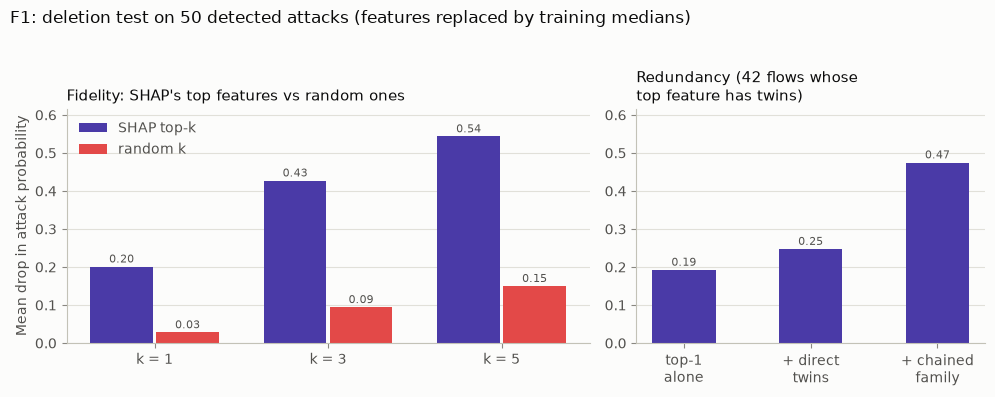

In [53]:
# STEP F1
# Figure: left, top-k vs random-k; right, top-1 alone vs top-1 with its twins.
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SHAP_COLOR, RANDOM_COLOR = "#4a3aa7", "#e34948"


def plain_axes(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelcolor=INK_2)


def label_bars(ax, bars):
    for bar in bars:
        ax.annotate(f"{bar.get_height():.2f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8, color=INK_2)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), facecolor=SURFACE,
                               gridspec_kw={"width_ratios": [3, 2]})
plain_axes(ax1); plain_axes(ax2)
x = np.arange(3)
w = 0.36
b1 = ax1.bar(x - w / 2 - 0.01, f1_topk["mean drop, SHAP top-k"], w, color=SHAP_COLOR, label="SHAP top-k")
b2 = ax1.bar(x + w / 2 + 0.01, f1_topk["mean drop, random-k"], w, color=RANDOM_COLOR, label="random k")
label_bars(ax1, b1); label_bars(ax1, b2)
ax1.set_xticks(x, [f"k = {k}" for k in f1_topk.index])
ax1.set_ylabel("Mean drop in attack probability", color=INK_2)
ax1.set_title("Fidelity: SHAP's top features vs random ones", color=INK, loc="left", fontsize=11)
ax1.legend(frameon=False, labelcolor=INK_2, loc="upper left")

vals = summary_group.loc["flows whose top feature has twins",
                         ["mean drop, top-1 alone", "mean drop, top-1 + twins", "mean drop, top-1 + chained family"]]
b3 = ax2.bar([0, 1, 2], vals.to_numpy(), 0.5, color=SHAP_COLOR)
label_bars(ax2, b3)
ax2.set_xticks([0, 1, 2], ["top-1\nalone", "+ direct\ntwins", "+ chained\nfamily"])
ax2.set_title(f"Redundancy ({int(has_twins.sum())} flows whose\ntop feature has twins)", color=INK,
              loc="left", fontsize=11)
top = max(ax1.get_ylim()[1], ax2.get_ylim()[1]) * 1.08
ax1.set_ylim(0, top); ax2.set_ylim(0, top)
fig.suptitle("F1: deletion test on 50 detected attacks (features replaced by training medians)",
             color=INK, x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig("results/figures/F1_deletion.png", dpi=150, facecolor=SURFACE)
plt.show()

<!-- STEP F1 -->
**What we found: SHAP's ranking is faithful.** Replacing the features SHAP ranks highest lowers the
attack probability far more than replacing random features:

| k | Mean drop, SHAP top-k | Mean drop, random k | Fidelity gap | Flows pushed below 0.5 |
|---|---|---|---|---|
| 1 | 0.20 | 0.03 | 0.17 | 0 of 50 |
| 3 | 0.43 | 0.09 | 0.33 | 10 of 50 |
| 5 | 0.54 | 0.15 | 0.39 | 30 of 50 |

The top feature alone does 7 times as much as a random one, and the top five push 30 of the 50
attacks to "benign". So SHAP is pointing at features the forest really uses for these flows.

**Single vs group.** For 39 of the 50 flows the top feature is `Bwd Packet Length Std`. Its only
*direct* twin above 0.95 is one other feature, but through a chain it belongs to a family of four
(`Bwd Packet Length Max`, `Mean`, `Std` and `Avg Bwd Segment Size`, T4 group 6). For the 42 flows whose
top feature has twins:

| Replaced with medians | Mean drop | Flows below 0.5 |
|---|---|---|
| top feature alone | 0.19 | 0 |
| + its direct twins (the lab's group) | 0.25 | 2 |
| + its whole chained family | **0.47** | **11** |

The lab's group (direct twins) adds little, because most top features have only one direct twin. The
full family more than doubles the drop: the information sits in the family, not in any single member.

**Check yourself: removing the top feature alone barely moved the score, but the group did. Was SHAP
wrong, or the test?** The test. SHAP was right that the information in `Bwd Packet Length Std` matters
(the group drop proves it), but that information is shared with three twins. Removing one member
leaves the other three, so the forest still sees almost the same evidence and the probability barely
moves (none of the 50 flows crosses 0.5). A single-feature deletion test measures what a feature adds
*on top of* its twins, which is small when the twins are close copies; SHAP instead splits the credit
for the shared information among the twins. Both are correct answers to different questions. With
correlated features, a deletion test has to remove whole groups, otherwise it will wrongly suggest that
SHAP over-rates its top features. And how the group is defined matters: the lab's direct-twin group
understated the effect; the chained family showed it.

<!-- STEP F2 -->
### Step F2: Do the numbers add up?

SHAP is built so that **base value + sum of all SHAP values = the model's output** for that flow. For
TreeSHAP this holds by construction; checking it shows what the numbers actually *are*.

**Correction to the lab's hint.** The lab says TreeSHAP returns log-odds, to be put through
`1 / (1 + exp(-x))` before comparing with `predict_proba`. That is true for gradient boosting, but
**not for a scikit-learn random forest**: a forest's output is the average of its trees' class
shares, which is already a probability, so TreeSHAP explains the probability directly. For the forest
the sum must match `predict_proba` *without* a sigmoid. We show both, and extra X6 below checks
gradient boosting, where the sigmoid is needed.

In [54]:
# STEP F2
f2_explainer = shap.TreeExplainer(rf)
y_explain = y_test.iloc[EXPLAIN_IDX].to_numpy()
# Five flows from EXPLAIN_IDX: the first two attacks and the first three benign flows.
f2_pos = np.concatenate([EXPLAIN_IDX[y_explain == 1][:2], EXPLAIN_IDX[y_explain == 0][:3]])
f2_flows = X_test.iloc[f2_pos]
f2_sv = f2_explainer(f2_flows)

f2 = pd.DataFrame({
    "attack_type": type_test.iloc[f2_pos].to_numpy(),
    "base_value": f2_sv.base_values[:, 1],
    "sum_shap": f2_sv.values[:, :, 1].sum(axis=1),
}, index=pd.Index(f2_pos, name="test_position"))
f2["total"] = f2["base_value"] + f2["sum_shap"]
f2["predict_proba"] = rf.predict_proba(f2_flows)[:, 1]
f2["difference"] = (f2["total"] - f2["predict_proba"]).abs()
f2["sigmoid(total)  (lab hint, wrong here)"] = 1 / (1 + np.exp(-f2["total"]))

assert (f2["difference"] < 0.001).all(), "base value + SHAP does not match the forest's probability"
print(f"Largest difference: {f2['difference'].max():.2e} (must be below 0.001)")
f2.to_csv("results/tables/F2_additivity.csv", float_format="%.6f")
f2.round(4)

Largest difference: 4.44e-16 (must be below 0.001)


,attack_type,base_value,sum_shap,total,predict_proba,difference,"sigmoid(total) (lab hint, wrong here)"
test_position,,,,,,,
50280,DDoS,0.1507,0.8493,1.0,1.0,0.0,0.7311
44005,DoS Hulk,0.1507,0.8493,1.0,1.0,0.0,0.7311
12428,BENIGN,0.1507,-0.1507,0.0,0.0,0.0,0.5000
72016,BENIGN,0.1507,-0.1507,0.0,0.0,0.0,0.5000
53224,BENIGN,0.1507,-0.1507,0.0,0.0,0.0,0.5000


<!-- STEP F2 -->
**What we found.** For all five flows, base value + SHAP sum equals the forest's attack probability to
within 5e-16 (rounding error), far inside the 0.001 the lab asks for. The forest is fully confident on
all five (probability exactly 1 for the two attacks, exactly 0 for the three benign flows), so the SHAP
values of an attack add up to +0.849 and those of a benign flow to −0.151. The base value (about 0.15) is the
forest's average attack probability over its training data, which is the attack rate. Each SHAP value
therefore says how many **percentage points of attack probability** a feature added or removed for
this flow. The column on the right shows what the lab's sigmoid hint would give: values squeezed
between 0.50 and 0.73, which match nothing. For a forest, the sigmoid is wrong.

**Check yourself: if the totals did not agree, what would that tell you about the explainer?** It would
mean the explainer is not describing the model we are scoring. The usual causes: the explanation is
in a different unit than we assume (log-odds vs probability, the very mistake the lab's hint invites);
the explainer was built for another model (e.g. a forest retrained after the explainer was created);
the explainer used an approximation (KernelSHAP or a sampled background) whose sum is only roughly
right; or the input was preprocessed differently for the explainer than for the model (scaled
vs raw). In all cases the per-feature numbers cannot be trusted, because they no longer add up to the
decision they claim to explain. TreeSHAP's exact additivity is what makes D1's and F1's numbers
meaningful as "percentage points of attack probability".

<!-- STEP F3 -->
### Step F3: How well does LIME fit?

LIME explains one flow by sampling thousands of slightly changed copies of it, asking the model about
each, and fitting a **straight line** (a weighted linear model) to the answers. Its explanation is the
slopes of that line. The slopes only mean something if the line fits the model well near the flow,
and LIME reports that fit as `exp.score`, an R² between 0 (useless) and 1 (perfect). Below about 0.70
the explanation should not be trusted much.

- LIME's statistics come from a **seeded 10,000-row sample of the training set** (much faster than
  all 267,984 rows, and enough to estimate each feature's quartiles).
- `discretize_continuous=True`: LIME works with ranges (quartiles) of each feature, because our
  features run from millions of bytes down to ratios near zero.
- **20 random test flows** (seed 42), as the lab asks. Because the forest is certain about almost
  every flow (probability exactly 0 or 1), we also explain **10 borderline test flows** with forest
  probability between 0.3 and 0.7, to answer whether the worst fits are the ones near 0.5.

In [55]:
# STEP F3
from lime.lime_tabular import LimeTabularExplainer

lime_rng = np.random.default_rng(SEED)
lime_background = X_train.to_numpy(dtype=float)[lime_rng.choice(len(X_train), 10_000, replace=False)]
lime_explainer = LimeTabularExplainer(lime_background, feature_names=FEATURES,
                                      class_names=["benign", "attack"],
                                      discretize_continuous=True, random_state=SEED)


def rf_predict_fn(a):
    """LIME passes numpy arrays; the forest was fitted on a DataFrame with named columns."""
    return rf.predict_proba(pd.DataFrame(a, columns=FEATURES))


random_pos = lime_rng.choice(len(X_test), 20, replace=False)
borderline_all = np.flatnonzero((rf_proba_test > 0.3) & (rf_proba_test < 0.7))
borderline_pos = lime_rng.choice(borderline_all, 10, replace=False)
print(f"{len(borderline_all)} test flows have forest probability between 0.3 and 0.7; 10 are explained")

start = time.time()
f3_rows = []
for group, positions in (("random", random_pos), ("borderline", borderline_pos)):
    for pos in positions:
        exp = lime_explainer.explain_instance(X_test.iloc[pos].to_numpy(dtype=float), rf_predict_fn,
                                              num_features=10)
        f3_rows.append({"group": group, "test_position": int(pos),
                        "attack_type": type_test.iloc[pos],
                        "forest_probability": rf_proba_test[pos],
                        "lime_r2": exp.score,
                        "lime_local_prediction": float(exp.local_pred[0]),
                        "top_feature": exp.as_list()[0][0]})
f3 = pd.DataFrame(f3_rows)
f3.to_csv("results/tables/F3_lime_fit.csv", index=False, float_format="%.4f")
print(f"LIME on {len(f3)} flows in {time.time() - start:.0f} s")

164 test flows have forest probability between 0.3 and 0.7; 10 are explained


LIME on 30 flows in 11 s


In [56]:
# STEP F3
rand = f3[f3["group"] == "random"]
worst = rand.loc[rand["lime_r2"].idxmin()]
print("20 random flows:")
print(rand[["test_position", "attack_type", "forest_probability", "lime_r2"]]
      .sort_values("lime_r2").round(3).to_string(index=False))
print(f"\nAttacks among them: {int((rand['attack_type'] != 'BENIGN').sum())} of 20")
print(f"Mean R² {rand['lime_r2'].mean():.3f}, minimum {rand['lime_r2'].min():.3f}, "
      f"{int((rand['lime_r2'] < 0.70).sum())} of 20 below 0.70")
print(f"Worst-fitting flow: position {int(worst['test_position'])} ({worst['attack_type']}), "
      f"forest probability {worst['forest_probability']:.3f}, R² {worst['lime_r2']:.3f}")

20 random flows:
 test_position attack_type  forest_probability  lime_r2
         75112      BENIGN               0.000    0.075
         59207      BENIGN               0.000    0.089
         14883      BENIGN               0.000    0.135
         68491      BENIGN               0.000    0.144
         19482      BENIGN               0.000    0.145
         35984      BENIGN               0.000    0.154
         83837    DoS Hulk               1.000    0.156
         58398      BENIGN               0.000    0.156
         39263      BENIGN               0.000    0.157
         61382      BENIGN               0.000    0.157
         69137      BENIGN               0.000    0.160
         46471      BENIGN               0.000    0.161
         18117      BENIGN               0.000    0.166
         57061      BENIGN               0.001    0.167
         62696      BENIGN               0.001    0.184
         58390      BENIGN               0.000    0.186
         72689      BENIGN     

In [57]:
# STEP F3
# Are the worst fits the flows near 0.5? Compare the two groups, and correlate R² with the distance
# of the forest's probability from 0.5.
from scipy.stats import spearmanr

summary = f3.groupby("group")["lime_r2"].agg(["count", "mean", "min", "max"])
summary["below 0.70"] = f3.assign(low=f3["lime_r2"] < 0.70).groupby("group")["low"].sum()
print(summary.round(3).to_string())
rho, pval = spearmanr(f3["lime_r2"], (f3["forest_probability"] - 0.5).abs())
print(f"\nSpearman(R², |probability - 0.5|) over all 30 flows: {rho:.3f} (p = {pval:.3f})")
print("\nBorderline flows:")
print(f3[f3["group"] == "borderline"][["attack_type", "forest_probability", "lime_r2",
                                         "lime_local_prediction"]].round(3).to_string(index=False))

            count   mean    min    max  below 0.70
group                                             
borderline     10  0.175  0.151  0.193          10
random         20  0.175  0.075  0.300          20

Spearman(R², |probability - 0.5|) over all 30 flows: -0.198 (p = 0.295)

Borderline flows:
attack_type  forest_probability  lime_r2  lime_local_prediction
     BENIGN               0.341    0.193                  0.244
   DoS Hulk               0.320    0.181                  0.263
   DoS Hulk               0.671    0.183                  0.271
        Bot               0.480    0.159                  0.262
   PortScan               0.439    0.151                  0.237
     BENIGN               0.551    0.187                  0.297
     BENIGN               0.419    0.171                  0.253
   DoS Hulk               0.580    0.172                  0.290
   DoS Hulk               0.340    0.172                  0.253
     BENIGN               0.604    0.184                  0.292


<!-- STEP F3 -->
**What we found.** LIME fits our forest **badly everywhere**. Over the 20 random flows (18 benign, 2 DoS
Hulk) the R² ranges from 0.075 to 0.300, with a **mean of 0.175**, and **all 20 are below 0.70**. The
worst fit (R² 0.075) is a benign flow the forest is certain about (probability 0.000). This is not a
setup error: Lab 3 ran LIME on a forest trained on the same CICIDS data and got the same picture (200
flows, mean R² 0.21, best 0.33, none above 0.70).

Why the straight line fits so badly: LIME builds its neighbourhood by drawing each feature
independently from the training quartiles, so most "neighbours" are unrealistic mixtures of flows. The
forest gives almost all of them a probability of 0 or 1, decided by sharp thresholds and interactions
between twin features. A weighted straight line over 68 "same quartile or not" indicators cannot follow
such a step-shaped surface. It does not even reproduce the forest's answer at the flow itself: for the
borderline flows LIME's line predicts 0.24–0.30 where the forest says 0.32–0.67.

**Check yourself: were the worst-fitting flows the ones near 0.5?** No. The worst fit is a flow with
probability 0.000, and the 10 borderline flows (probability 0.32–0.67) fit neither better nor worse
than the random ones (same mean R² 0.175, range 0.15–0.19). There is no clear link between the fit and
the distance from 0.5 (Spearman −0.20, p = 0.30). The expectation that borderline flows fit worst
assumes a model that is smooth elsewhere; our forest is not smooth anywhere, so LIME's line fits
poorly whether the flow is certain or borderline.

**Check yourself: which of the three checks could run automatically on every alert, and why?**

- **F3 (LIME fit)** is the most useful one to run on every alert: LIME computes `exp.score` anyway when
  it explains a flow, so the check is free. A rule such as "R² below 0.70 → show the explanation with a
  warning, or do not show it" can be applied to every alert. On our forest it would flag *every*
  LIME explanation, which is itself a finding: LIME should not be the explanation analysts see for this
  model.
- **F2 (additivity)** is also free and automatic (one sum per alert), but for TreeSHAP it holds by
  construction, so it only catches set-up errors (wrong model, wrong unit), not misleading explanations.
- **F1 (deletion test)** needs extra model calls per alert (the top-k features and a few random sets
  replaced by medians), so it is feasible per alert but costs more; it is better run regularly on a
  sample of alerts to monitor whether the explanations stay faithful.

<!-- STEP X1 -->
### Extra X1: a whole group of fields fails at once

In a real collector, fields do not go missing one at a time: a whole group fails together. Here we
replace **every backward-direction feature** (17 features, everything the responder sends) or **every
idle timer** (4 features) with the training median, in every test flow. For a fair comparison we also
run random missingness of the same size: 25% random (17 features per row) and 6% random (4 per row).

In [58]:
# STEP X1
BWD_COLS = [c for c in FEATURES if "Bwd" in c or "backward" in c.lower()]
IDLE_COLS = [c for c in FEATURES if c.startswith("Idle")]


def drop_group(X, cols):
    """Copy of X with the whole group of columns set to the training median."""
    out = X.copy()
    out[cols] = np.broadcast_to(TRAIN_MEDIAN[cols].to_numpy(), (len(X), len(cols)))
    return out


scenarios = {
    "random 10% (7 per row)": add_missing(X_test, 0.10),
    f"all backward ({len(BWD_COLS)})": drop_group(X_test, BWD_COLS),
    f"random {len(BWD_COLS)} per row": add_missing(X_test, len(BWD_COLS) / len(FEATURES)),
    f"all idle timers ({len(IDLE_COLS)})": drop_group(X_test, IDLE_COLS),
    f"random {len(IDLE_COLS)} per row": add_missing(X_test, len(IDLE_COLS) / len(FEATURES)),
}
group_rows = [{"scenario": s, "model": name, **report(model, Xs, y_test)}
              for s, Xs in scenarios.items() for name, model in MODELS.items()]
group_missing = pd.DataFrame(group_rows)
group_missing.to_csv("results/tables/X1_group_missing.csv", index=False, float_format="%.4f")
print("Macro-F1")
print(group_missing.pivot(index="scenario", columns="model", values="macro_f1")
      .loc[list(scenarios)].round(4).to_string())
print("\nRecall")
print(group_missing.pivot(index="scenario", columns="model", values="recall")
      .loc[list(scenarios)].round(4).to_string())

Macro-F1
model                   forest  logreg    tree
scenario                                      
random 10% (7 per row)  0.9900  0.7776  0.8763
all backward (17)       0.4603  0.6370  0.6165
random 17 per row       0.8921  0.7098  0.7306
all idle timers (4)     0.9944  0.9076  0.9949
random 4 per row        0.9957  0.8268  0.9270

Recall
model                   forest  logreg    tree
scenario                                      
random 10% (7 per row)  0.9681  0.6092  0.7462
all backward (17)       0.0010  0.2428  0.2082
random 17 per row       0.6829  0.5467  0.4653
all idle timers (4)     0.9843  0.7297  0.9879
random 4 per row        0.9886  0.6685  0.8509


<!-- STEP X1 -->
**Check yourself: would a whole group failing together be worse?** Yes, much worse, if it is a group the
model relies on. Losing **all 17 backward features** at once leaves the forest with a recall of
**0.001**: it misses practically every attack. The same number of values missing *at random* (17 per
row) still leaves it 0.68. The reason is the twins again: random missingness almost always leaves a twin
of each lost feature behind, but a group failure takes out the feature *and* its twins (T4 found that
9 of the 17 backward features sit in twin groups 2, 6 and 11). Losing all four idle timers, on the other
hand, costs almost nothing (forest macro-F1 0.994), because the forest hardly uses them. So our
random-10% simulation is optimistic: a realistic collector failure can be far more damaging, depending
on which group fails.

<!-- STEP X2 -->
### Extra X2: does clipping at zero change the results?

The same experiment without clipping, next to the clipped run.

In [59]:
# STEP X2
clip_cmp = noise_all.pivot_table(index=["model", "level"], columns="clip",
                                 values=["macro_f1", "recall"])
clip_cmp.columns = [f"{m}_{'clipped' if c else 'not_clipped'}" for m, c in clip_cmp.columns]
clip_cmp["macro_f1_diff"] = clip_cmp["macro_f1_clipped"] - clip_cmp["macro_f1_not_clipped"]
clip_cmp["recall_diff"] = clip_cmp["recall_clipped"] - clip_cmp["recall_not_clipped"]
clip_cmp.to_csv("results/tables/X2_clip_vs_noclip.csv", float_format="%.4f")
clip_cmp.round(4)

macro_f1_not_clipped  macro_f1_clipped  recall_not_clipped  \
model  level                                                               
forest 0.00                 0.9968            0.9968              0.9923   
       0.05                 0.5212            0.5212              0.0633   
       0.10                 0.5082            0.5082              0.0494   
       0.20                 0.4970            0.4970              0.0377   
       0.50                 0.4798            0.4798              0.0202   
logreg 0.00                 0.9416            0.9416              0.8320   
       0.05                 0.9001            0.9085              0.8405   
       0.10                 0.8352            0.8561              0.8338   
       0.20                 0.7280            0.7521              0.7935   
       0.50                 0.5891            0.5964              0.7092   
tree   0.00                 0.9970            0.9970              0.9950   
       0.05                 0.3992            0.3992              0.1092   
       0.10                 0.3961            0.3961              0.1079   
       0.20                 0.3962            0.3962              0.1126   
       0.50                 0.3946            0.3946              0.1332   

              recall_clipped  macro_f1_diff  recall_diff  
model  level                                              
forest 0.00           0.9923         0.0000       0.0000  
       0.05           0.0633         0.0000       0.0000  
       0.10           0.0494         0.0000       0.0000  
       0.20           0.0377         0.0000       0.0000  
       0.50           0.0202         0.0000       0.0000  
logreg 0.00           0.8320         0.0000       0.0000  
       0.05           0.8364         0.0084      -0.0041  
       0.10           0.8308         0.0210      -0.0030  
       0.20           0.7920         0.0241      -0.0015  
       0.50           0.7029         0.0073      -0.0062  
tree   0.00           0.9950         0.0000       0.0000  
       0.05           0.1092         0.0000       0.0000  
       0.10           0.1079         0.0000       0.0000  
       0.20           0.1126         0.0000       0.0000  
       0.50           0.1332         0.0000       0.0000

<!-- STEP X2 -->
Clipping makes no difference for the two tree models and a small one for logistic regression (macro-F1
+0.007 to +0.024 at 5–50% noise), whose linear score does react to an impossible negative value.

<!-- STEP X6 -->
### Extra X6: the same check for gradient boosting

Gradient boosting adds up the outputs of its trees in **log-odds**, and turns the total into a
probability with the sigmoid at the very end. TreeSHAP explains the log-odds, and returns one value per
feature (no class axis), so here the lab's hint is exactly right.

In [60]:
# STEP X6
gb_sv = shap.TreeExplainer(gb)(f2_flows)
print("SHAP values shape for gradient boosting:", gb_sv.values.shape, "(no class axis)")
x6 = pd.DataFrame({
    "base_value (log-odds)": np.asarray(gb_sv.base_values).reshape(-1),
    "sum_shap (log-odds)": gb_sv.values.sum(axis=1),
}, index=f2.index)
x6["total (log-odds)"] = x6["base_value (log-odds)"] + x6["sum_shap (log-odds)"]
x6["sigmoid(total)"] = 1 / (1 + np.exp(-x6["total (log-odds)"]))
x6["predict_proba"] = gb.predict_proba(f2_flows)[:, 1]
x6["difference after sigmoid"] = (x6["sigmoid(total)"] - x6["predict_proba"]).abs()
x6["difference without sigmoid"] = (x6["total (log-odds)"] - x6["predict_proba"]).abs()
assert (x6["difference after sigmoid"] < 0.001).all()
x6.to_csv("results/tables/X6_gb_additivity.csv", float_format="%.6f")
x6.round(4)

SHAP values shape for gradient boosting: (5, 68) (no class axis)


,base_value (log-odds),sum_shap (log-odds),total (log-odds),sigmoid(total),predict_proba,difference after sigmoid,difference without sigmoid
test_position,,,,,,,
50280,-5.6059,13.7884,8.1825,0.9997,0.9997,0.0,7.1828
44005,-5.6059,12.6125,7.0066,0.9991,0.9991,0.0,6.0075
12428,-5.6059,-3.1032,-8.7091,0.0002,0.0002,0.0,8.7093
72016,-5.6059,-3.0729,-8.6787,0.0002,0.0002,0.0,8.6789
53224,-5.6059,-3.1032,-8.7091,0.0002,0.0002,0.0,8.7093


<!-- STEP X6 -->
For gradient boosting the totals are log-odds (large positive for attacks, large negative for benign
flows) and only match `predict_proba` after the sigmoid. So the unit of a SHAP value depends on the
model: percentage points of probability for our forest, log-odds for gradient boosting. Comparing SHAP
numbers across the two models without converting would be meaningless.